# Análise Exploratória e Pré-processamento de Dados
## Dataset: Taxas dos Títulos Ofertados pelo Tesouro Direto

---

**Disciplina:** Análise de Dados e Boas Práticas  
**Especialização:** Ciência de Dados — PUC  
**Autor:** Marcio Goulart Mocellin  
**Matrícula:** 4052026000399  
**Data:** Março de 2026

---

Este notebook serve como relatório técnico e acadêmico cobrindo as etapas de:
1. Definição do problema
2. Pré-processamento dos dados
3. Análise exploratória dos dados (EDA)

O dataset utilizado é o **Taxas dos Títulos Ofertados pelo Tesouro Direto**, disponibilizado publicamente pelo Tesouro Nacional por meio da plataforma [Tesouro Transparente](https://www.tesourotransparente.gov.br).

---
## 1. Definição do Problema

### 1.1 Descrição do Problema

O **Tesouro Direto** é um programa do Governo Federal brasileiro que permite a compra e venda de títulos públicos federais por pessoas físicas, diretamente pela internet. Os títulos disponíveis incluem opções pós-fixadas e prefixadas, cada uma com características distintas de prazo e rentabilidade.

A escolha do título mais adequado para investimento depende do objetivo do investidor, seja guardar para aposentadoria (Tesouro Renda+ Aposentadoria Extra), investir em educação superior dos filhos (Tesouro Educa+), comprar um imóvel (Tesouro IGPM+ com Juros Semestrais) ou simplesmente obter uma rentabilidade superior à poupança, assim como dependerá do tempo de investimento planejado. Sobre o risco associado, os títulos do Tesouro Direto são considerados os mais baixo risco do mercado, pois são garantidos pelo Tesouro Nacional.

Outros investimentos, como ações, fundos imobiliários e criptomoedas, podem oferecer potencial de retorno mais elevado, mas também apresentam maior volatilidade e risco de perda. Dessa forma, o investidor deve ponderar o risco e o retorno esperado antes de escolher sobre o quanto deseja investir nesses títulos. A alternativa mais sábia é diversificar a carteira de investimentos, usando os titulos do Tesouro para diluir o risco da carteira com investimentos mais arriscados, mas com potencial de retorno mais elevado.

Este trabalho utiliza o dataset de **preços e taxas diários** dos títulos ofertados no Tesouro Direto, cujo objetivo analítico é entender o comportamento histórico das taxas de rentabilidade e preços unitários, identificar padrões sazonais e tendências de longo prazo, e preparar os dados para modelos preditivos futuros. Não se pretende trabalhar com um titulo específico, mas sim analisar o comportamento geral do mercado de títulos públicos ao longo do tempo. Já se sabe de antemão que a análise agregada dos títulos mascarará comportamentos específicos de cada título e aumentará a variância dos dados como um todo, o que dificultará a identificação de padrões e tendências.

**Fonte do dataset:**
- CSV: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv
- Metadados: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/1a8eb2e3-4902-4a38-a1eb-6410f23d90de/download/taxa.pdf

### 1.2 Tipo de Problema

Trata-se predominantemente de um problema de **aprendizado não supervisionado** nesta etapa: não há uma variável-alvo explícita para previsão imediata. A análise exploratória busca descobrir padrões, agrupamentos e tendências nos dados. Em etapas futuras, o problema poderia ser reformulado como **supervisionado** para, por exemplo, prever a taxa de um título para determinada o melhormomento de compra de um título.

### 1.3 Hipóteses e Premissas

- **H1:** O Tesouro Direto possui uma estratégia de diversificação do perfil de vencimentos e de suavização do desembolso futuro da dívida pública.
- **H2:** Os títulos pós-fixados apresentam a distribuição de taxas semelhante à dos títulos prefixados.
- **H3:** Estabelecer correlação entre a taxa de rentabilidade e o preço unitário do título: quanto maior a taxa, menor o preço.
- **H4:** Títulos com prazos de vencimento mais longos tendem a oferecer taxas mais elevadas como prêmio de risco.
- **H5:** A sazonalidade pode influenciar as taxas, com variações mais significativas em determinado dia da semana ou dia do mês.

### 1.4 Restrições para Seleção dos Dados

- Serão considerados **todos os registros históricos** disponíveis no dataset sem filtro de período inicial.
- Serão retirados da analise os titulos que possam apresentar dados inconsistentes ou incompletos.

### 1.5 Definição dos Atributos

| Atributo | Tipo | Descrição |
|---|---|---|
| `Tipo Titulo` | Categórico (nominal) | Nome comercial do título público |
| `Data Vencimento` | Data | Data em que o título vence e o investidor recebe o valor de face |
| `Data Base` | Data | Data de referência do registro (data do pregão) |
| `Taxa Compra Manha` | Numérico (contínuo) | Taxa de compra registrada no período da manhã, em % ao ano |
| `Taxa Venda Manha` | Numérico (contínuo) | Taxa de venda registrada no período da manhã, em % ao ano |
| `PU Compra Manha` | Numérico (contínuo) | Preço unitário de compra — manhã, em R$ |
| `PU Venda Manha` | Numérico (contínuo) | Preço unitário de venda — manhã, em R$ |
| `PU Base Manha` | Numérico (contínuo) | Preço unitário base (valor de referência) — manhã, em R$ |

Observação: No arquivo fornecido as variaveis contínuas apresentam no máximo duas casas após a vírgula

---
## 2. Importação de Bibliotecas

As bibliotecas escolhidas são amplamente utilizadas na comunidade de ciência de dados com Python e já estão disponíveis no Google Colab sem necessidade de instalação adicional.

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import holidays
from matplotlib import __version__ as matversion
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from textwrap import fill
import seaborn as sns
from scipy import stats
from sklearn import __version__ as skversion
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configurações globais de visualização
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

print("Hoje é dia", dt.datetime.now().strftime("%Y-%m-%d"))
print("Bibliotecas importadas com sucesso.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  seaborn : {sns.__version__}")
print(f"  matplotlib : {matversion}")
print(f"  sklearn : {skversion}")

Hoje é dia 2026-03-23
Bibliotecas importadas com sucesso.
  pandas  : 2.2.2
  numpy   : 2.0.2
  seaborn : 0.13.2
  matplotlib : 3.10.0
  sklearn : 1.6.1


---
## 3. Carregamento e Inspeção Inicial dos Dados

### 3.1 Carregamento do Dataset

O arquivo CSV é carregado diretamente da URL pública do Tesouro Transparente. O separador utilizado é o ponto e vírgula (`;`) e o separador decimal é a vírgula (`,`), padrão brasileiro. As colunas de data são convertidas automaticamente para o tipo `datetime`.

In [2]:
URL = (
    "https://www.tesourotransparente.gov.br/ckan/dataset/"
    "df56aa42-484a-4a59-8184-7676580c81e3/resource/"
    "796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv"
)

df_raw = pd.read_csv(
    URL,
    sep=";",
    decimal=",",
    parse_dates=["Data Vencimento", "Data Base"],
    dayfirst=True,
)

print(f"Dataset carregado com sucesso.")
print(f"Dimensões: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")

Dataset carregado com sucesso.
Dimensões: 168,938 linhas x 8 colunas


### 3.2 Primeiras Linhas

Inspecionamos as cinco primeiras linhas para verificar se o carregamento ocorreu corretamente e identificar eventuais problemas óbvios.

In [3]:
df_raw.head()

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
0,Tesouro Prefixado,2013-01-01,2011-05-11,12.62,12.67,823.01,822.41,822.02
1,Tesouro Prefixado,2011-07-01,2011-05-11,12.06,12.09,984.30,984.27,983.82
2,Tesouro Prefixado,2012-01-01,2011-05-11,12.35,12.39,927.87,927.66,927.23
3,Tesouro Prefixado,2015-01-01,2011-05-11,12.68,12.74,647.02,645.77,645.46
4,Tesouro IPCA+ com Juros Semestrais,2035-05-15,2011-05-11,5.95,6.05,2118.28,2093.01,2091.99


### 3.3 Últimas Linhas

In [4]:
df_raw.tail()

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
168933,Tesouro Prefixado,2006-10-01,2005-07-22,18.11,18.15,820.78,820.45,819.91
168934,Tesouro Prefixado,2006-07-01,2005-07-22,18.31,18.35,854.87,854.60,854.03
168935,Tesouro Prefixado,2006-04-01,2005-07-22,18.68,18.72,888.47,888.26,887.66
168936,Tesouro Prefixado,2005-10-01,2005-07-22,19.70,19.73,965.63,965.59,964.90
168937,Tesouro Prefixado,2006-01-01,2005-07-22,19.23,19.26,925.45,925.34,924.70


### 3.4 Tipos de Dados e Informações Gerais

Verificamos os tipos de cada coluna e a presença de valores nulos.

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168938 entries, 0 to 168937
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Tipo Titulo        168938 non-null  object        
 1   Data Vencimento    168938 non-null  datetime64[ns]
 2   Data Base          168938 non-null  datetime64[ns]
 3   Taxa Compra Manha  168938 non-null  float64       
 4   Taxa Venda Manha   168938 non-null  float64       
 5   PU Compra Manha    168938 non-null  float64       
 6   PU Venda Manha     168938 non-null  float64       
 7   PU Base Manha      168938 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(1)
memory usage: 10.3+ MB


**Observações sobre a inspeção inicial:**

- O dataset possui **8 colunas** e um número expressivo de linhas, acumulando registros diários desde o início do programa Tesouro Direto.
- As colunas de data (`Data Vencimento`, `Data Base`) foram corretamente interpretadas como `datetime64[ns]`.
- As colunas numéricas foram lidas como `float64` graças à configuração do separador decimal.
- A coluna `Tipo Titulo` é do tipo `object` (string), o que é esperado para dados categóricos nominais.


---
## 4. Pré-processamento dos Dados

### 4.1 Visão Geral das Operações

Com base na análise exploratória, as seguintes operações de pré-processamento são realizadas:

1. **Análise de zeros** — valores zero nas colunas numéricas podem indicar ausência de cotação, assim como valores muito próximos de zero.
2. **Remoção de registros com todos os valores numéricos ausentes** — registros totalmente vazios não contribuem para a análise.
3. **Engenharia de atributos** — criação de novas colunas derivadas úteis para análise.
4. **Normalização (Min-Max Scaling)** — escala todos os atributos numéricos para o intervalo [0, 1].
5. **Padronização (Z-score)** — transforma os atributos para média 0 e desvio-padrão 1.
6. **Discretização das taxas** — converte as taxas contínuas em faixas categóricas ordinais.
7. **One-hot encoding do Tipo Título** — transforma a variável categórica em colunas binárias.

### 4.2 Análise de inconsistências

Quando se depara com valores zerados em colunas numéricas tem que se investigar o motivo. É muito comum que valores zerados em datasets financeiros intiquem o truncamento do valor real do titulo, ou seja, o valor real no titulo é muito baixo, mas o sistema de coleta de dados não consegue registrar o valor real e acaba registrando como zero. Outros motivos para valores zerados podem ser a ausência de cotação para aquele título em um determinado dia, ou mesmo um erro de coleta ou registro dos dados.  

#### 4.2.1 Indícios de truncamento de dados

In [6]:
df_zero = df_raw.loc[(df_raw['Taxa Compra Manha'] == 0), ['Tipo Titulo', 'Data Vencimento', 'Data Base']].sort_values(by='Data Base', ascending=False)

feriados_br = holidays.Brazil(
    years=sorted(df_zero["Data Base"].dt.year.unique())
)
# Extrair dia da semana (0=segunda, 6=domingo)
df_zero["dia_semana"] = df_zero["Data Base"].dt.dayofweek
df_zero["nome_dia"] = df_zero["Data Base"].dt.day_name()

# Mapear para português
mapa_dias = {
    0: "Segunda", 1: "Terça", 2: "Quarta", 3: "Quinta",
    4: "Sexta", 5: "Sábado", 6: "Domingo"
}
df_zero["dia_semana_pt"] = df_zero["dia_semana"].map(mapa_dias)
datas_base = df_zero["Data Base"].dt.normalize()
df_zero["eh_feriado"] = datas_base.map(lambda data: data in feriados_br)
# df_zero["nome_feriado"] = datas_base.map(lambda data: feriados_br.get(data))
df_zero

,Tipo Titulo,Data Vencimento,Data Base,dia_semana,nome_dia,dia_semana_pt,eh_feriado
59467,Tesouro Selic,2027-03-01,2026-03-20,4,Friday,Sexta,False
59530,Tesouro Selic,2027-03-01,2026-03-19,3,Thursday,Quinta,False
53522,Tesouro Selic,2027-03-01,2026-03-18,2,Wednesday,Quarta,False
53582,Tesouro Selic,2027-03-01,2026-03-17,1,Tuesday,Terça,False
53946,Tesouro Selic,2027-03-01,2026-03-16,0,Monday,Segunda,False
...,...,...,...,...,...,...,...
28772,Tesouro Selic,2006-01-18,2005-11-22,1,Tuesday,Terça,False
28801,Tesouro Selic,2006-01-18,2005-11-21,0,Monday,Segunda,False
165174,Tesouro Selic,2005-02-16,2005-01-04,1,Tuesday,Terça,False
165202,Tesouro Selic,2005-02-16,2005-01-03,0,Monday,Segunda,False


In [7]:
print(f"Total de registros com Taxa Compra Manhã = 0: {len(df_zero):,}")
print(f"Distribuição por dia da semana:")
print(df_zero["dia_semana_pt"].value_counts())
print(f"\nTotal de registros que caem em feriados: {df_zero['eh_feriado'].sum()}")
del df_zero, feriados_br, mapa_dias, datas_base

Total de registros com Taxa Compra Manhã = 0: 7,695
Distribuição por dia da semana:
dia_semana_pt
Quarta     1568
Sexta      1537
Quinta     1537
Terça      1532
Segunda    1521
Name: count, dtype: int64

Total de registros que caem em feriados: 0


Não ocorreram registros em eventos como feriados, finais de semana ou outros fatores externos e se observou o registros com taxa de compra igual a zero  ocorreram em dias ordinários, o que sugere que esses valores zerados podem ser resultado do truncamento de dados, indicando que o valor real da taxa era muito próximo de zero para ser registrado corretamente.  
Agora analizaremos a vizinhança desses registros para entender melhor o comportamento dos dados.

In [8]:
df_raw.loc[(df_raw['Tipo Titulo'] == 'Tesouro Selic') & (df_raw['Data Vencimento'] == '2026-03-01 00:00:00') & (df_raw['Data Base'].isin(pd.date_range('2025-12-17', '2025-12-30'))), :].sort_values(by='Data Base', ascending=False)


,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
58521,Tesouro Selic,2026-03-01,2025-12-30,0.01,0.02,18095.50,18075.13,18075.13
58881,Tesouro Selic,2026-03-01,2025-12-29,0.01,0.02,18075.61,18065.28,18065.28
58941,Tesouro Selic,2026-03-01,2025-12-26,0.01,0.02,18065.72,18055.38,18055.38
59299,Tesouro Selic,2026-03-01,2025-12-23,0.00,0.01,18055.83,18035.49,18035.49
59359,Tesouro Selic,2026-03-01,2025-12-22,0.01,0.02,18035.88,18025.53,18025.53
53754,Tesouro Selic,2026-03-01,2025-12-19,0.01,0.02,18025.92,18015.58,18015.58
54117,Tesouro Selic,2026-03-01,2025-12-18,0.01,0.02,18015.95,18005.60,18005.60
54175,Tesouro Selic,2026-03-01,2025-12-17,0.01,0.02,18005.93,17995.59,17995.59


O valor de zero na serie temporal `Taxa Compra Manha` na Data Base de 2025-12-23 está cercado por registros com taxas muito próximas de zero, reforçando a hipótese de truncamento de dados.

#### 4.2.2 Riscos inerentes ao truncamento de dados

Inicialmente se observará o histograma da coluna `Taxa Venda Manha` para verificar a distribuição dos valores.

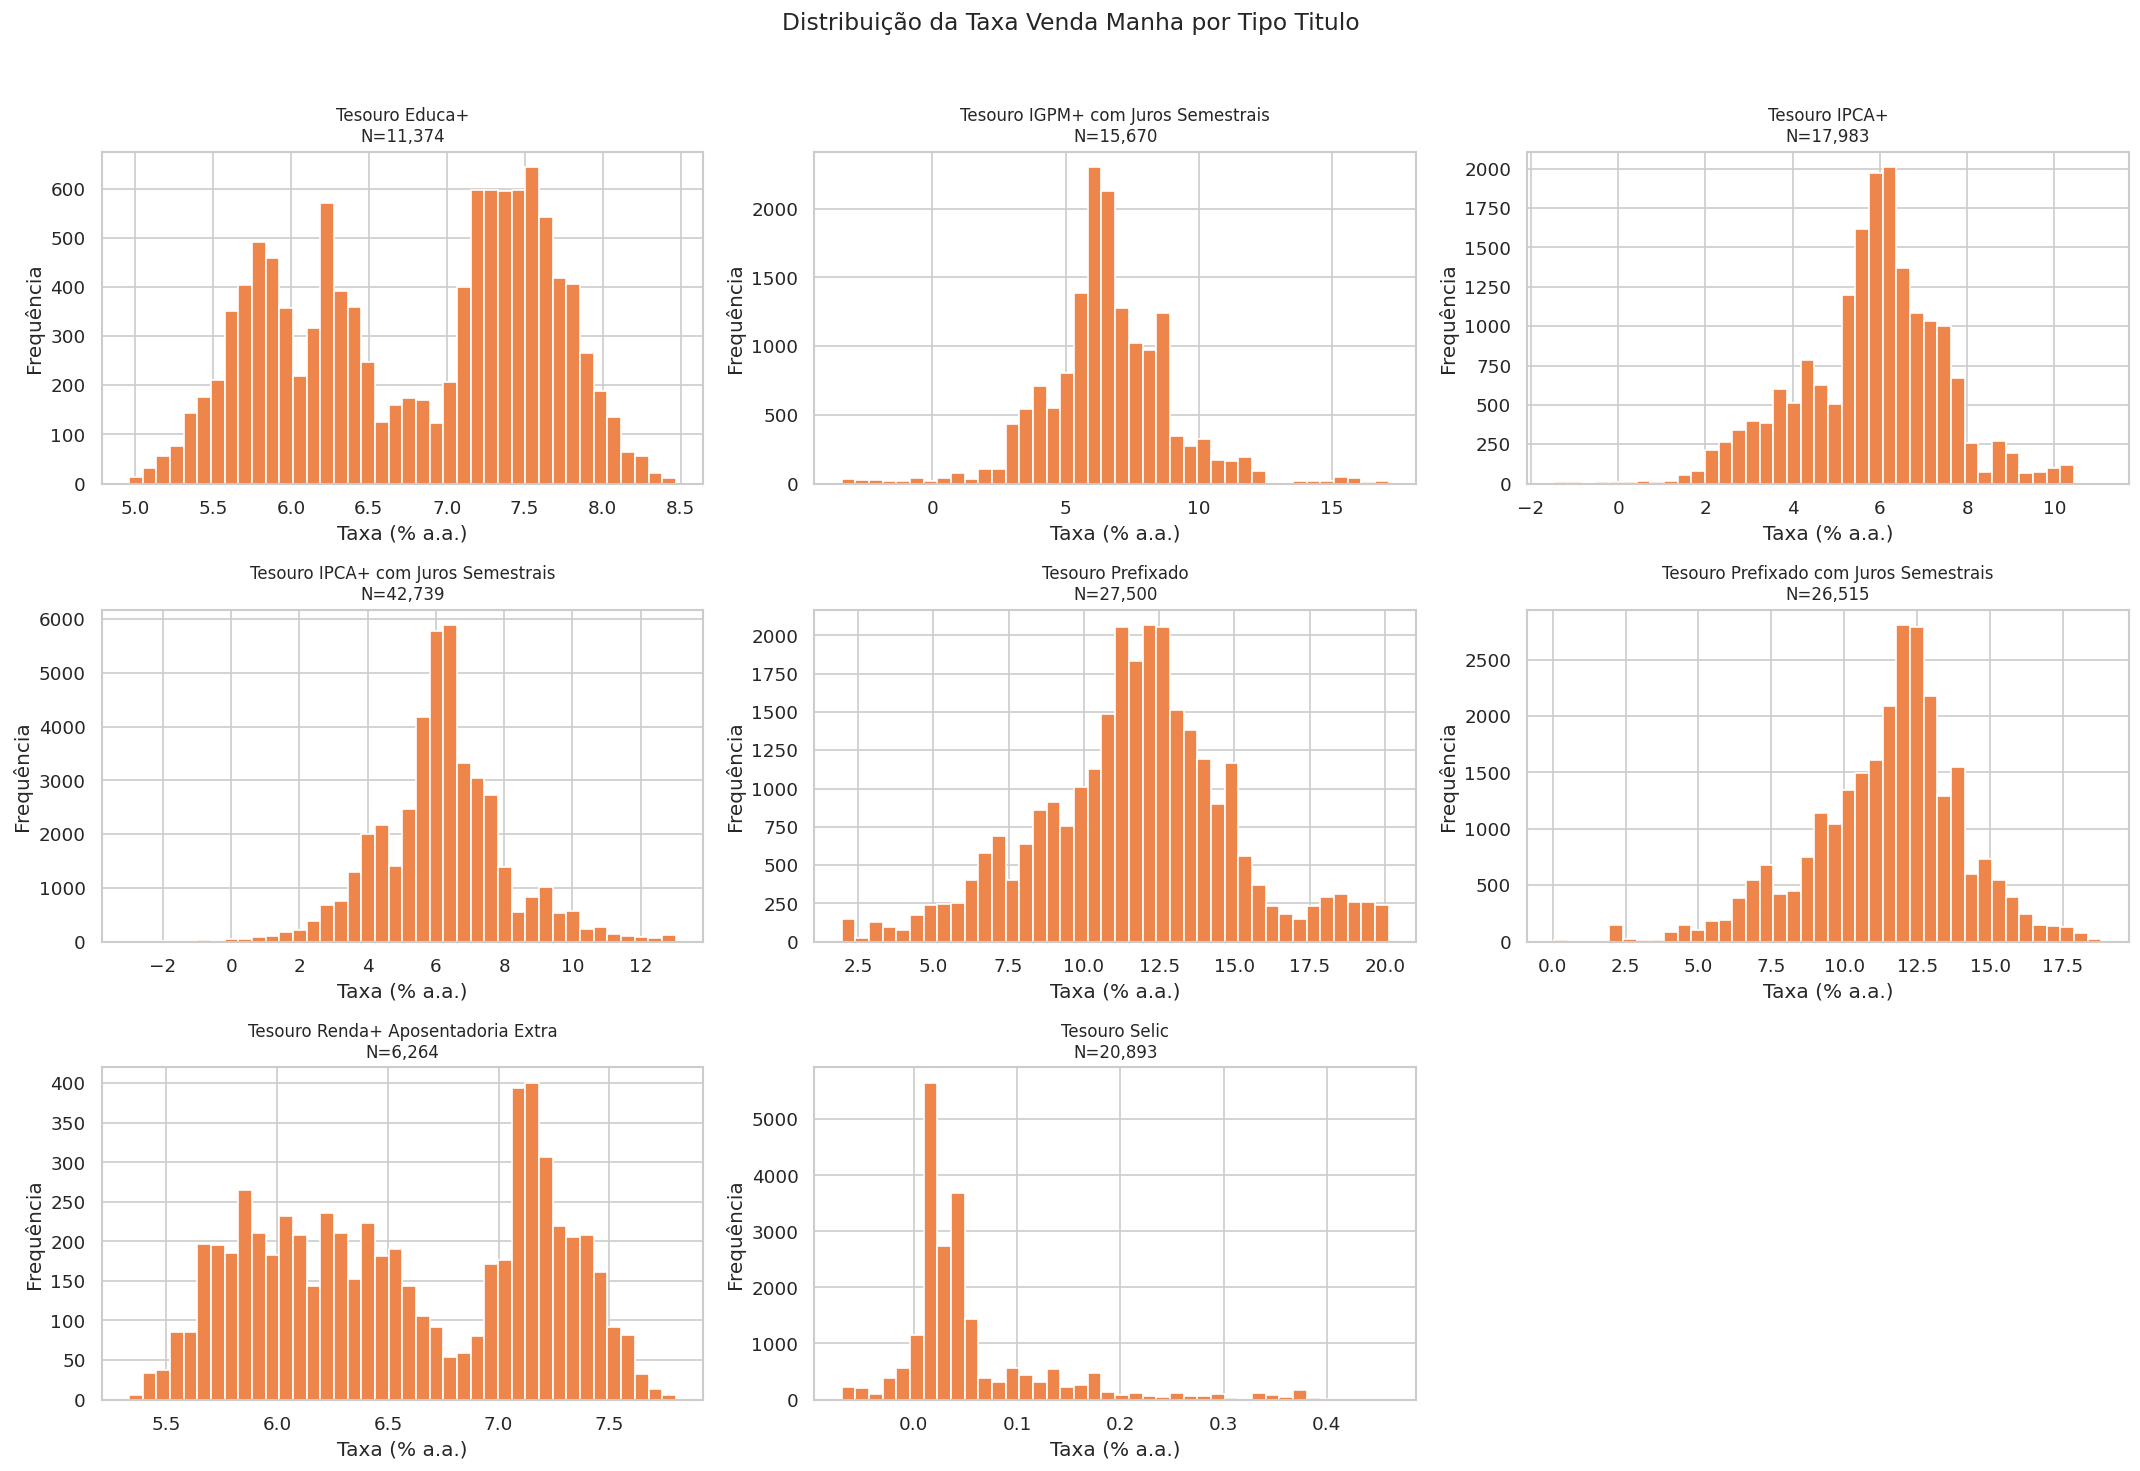

In [9]:
# Histograma de Taxa Venda Manha por Tipo Titulo

tipos = sorted(df_raw["Tipo Titulo"].dropna().unique())

n_cols = 3
n_rows = int(np.ceil(len(tipos) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

cor = sns.color_palette("muted")[1]

for i, tipo in enumerate(tipos):
    ax = axes[i]
    subset = df_raw.loc[df_raw["Tipo Titulo"] == tipo, "Taxa Venda Manha"].dropna()
    ax.hist(subset, bins=40, color=cor, edgecolor="white")
    ax.set_title(f"{tipo}\nN={len(subset):,}", fontsize=10)
    ax.set_xlabel("Taxa (% a.a.)")
    ax.set_ylabel("Frequência")

# Esconde eixos sobrando (quando grade > quantidade de tipos)
for j in range(len(tipos), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribuição da Taxa Venda Manha por Tipo Titulo", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Como o titulo `Tesouro Selic` apresenta se muito centrado em valores próximos de zero e sua dispersão é muito baixa, na casa dos décimos, a presença de truncamento de dados pode distorcer significativamente as análises estatísticas e os modelos preditivos, levando a conclusões errôneas sobre o comportamento das taxas e preços dos títulos. Desta forma se preferirá remover este titulo da análise, pois ele não apresenta segurança suficiente para contribuir com insights relevantes e pode introduzir ruído nos modelos preditivos.

In [ ]:
df_pre = df_raw.loc[~(df_raw['Tipo Titulo'] == 'Tesouro Selic'), :]

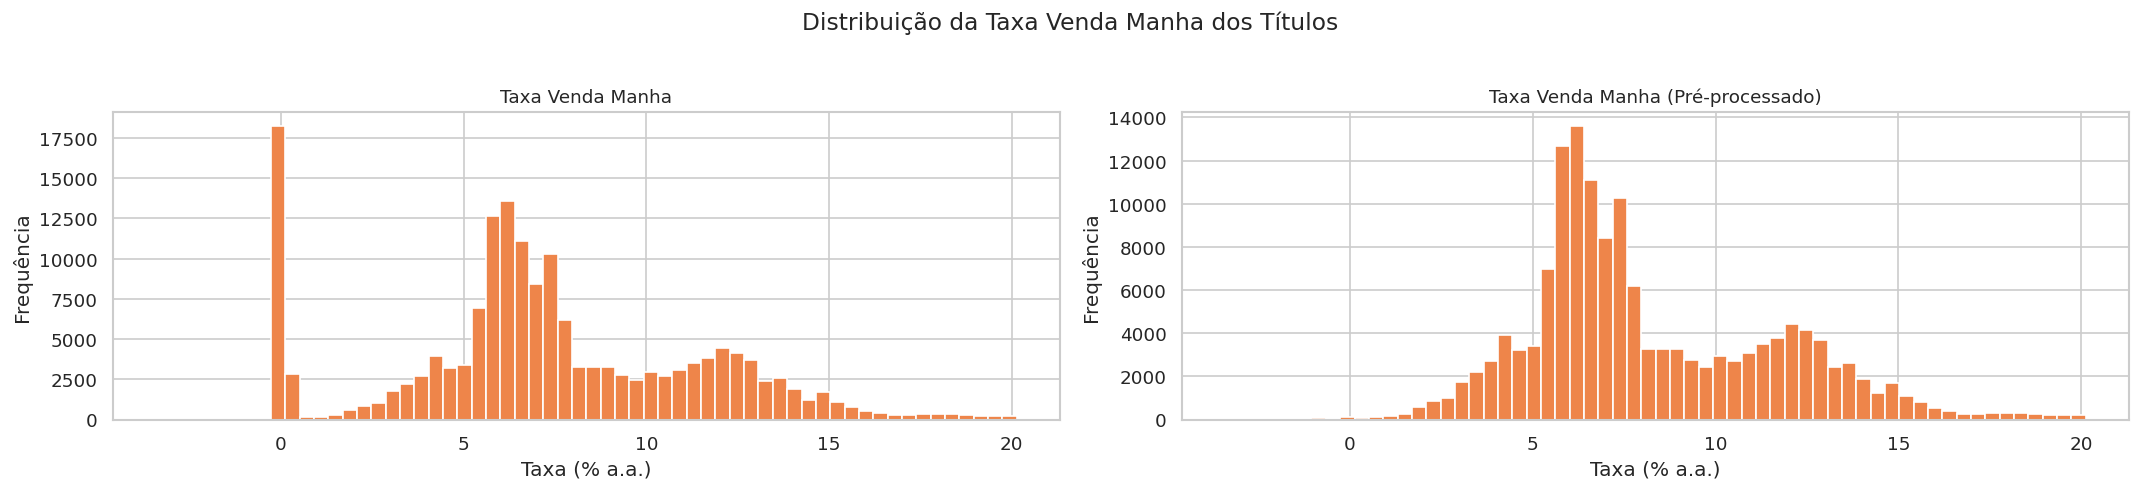

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4 * 1))

ax = axes[0]
df_raw["Taxa Venda Manha"].hist(bins=60, color=sns.color_palette("muted")[1], edgecolor="white", ax=ax)
ax.set_title("Taxa Venda Manha", fontsize=11)
ax.set_xlabel("Taxa (% a.a.)")
ax.set_ylabel("Frequência")

ax = axes[1]
df_pre["Taxa Venda Manha"].hist(bins=60, color=sns.color_palette("muted")[1], edgecolor="white", ax=ax)
ax.set_title("Taxa Venda Manha (Pré-processado)", fontsize=11)
ax.set_xlabel("Taxa (% a.a.)")
ax.set_ylabel("Frequência")

plt.suptitle("Distribuição da Taxa Venda Manha dos Títulos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
colunas_numericas = df_pre.select_dtypes(include="number").columns.tolist()

print("Zeros encontrados nas colunas numéricas:")
for col in colunas_numericas:
    zeros_antes = (df_raw[col] == 0).sum()
    
    # df_raw[col] = df_raw[col].replace(0, np.nan)
    print(f"  {col:25s}: {zeros_antes:5,} zeros")

print(f"\nTotal de linhas com zeros: {(df_raw == 0).sum().sum():,}")
print(f"Dimensões do dataset: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
print("\n" + "-" * 50 + "\n")
print("Zeros encontrados nas colunas numéricas (Pré-processado):")
for col in colunas_numericas:
    zeros_antes = (df_pre[col] == 0).sum()
    
    # df_pre[col] = df_pre[col].replace(0, np.nan)
    print(f"  {col:25s}: {zeros_antes:5,} zeros")

print(f"\nTotal de linhas com zeros: {(df_pre == 0).sum().sum():,}")
print(f"Dimensões do dataset: {df_pre.shape[0]:,} linhas x {df_pre.shape[1]} colunas")

Zeros encontrados nas colunas numéricas:
  Taxa Compra Manha        : 7,695 zeros
  Taxa Venda Manha         : 1,152 zeros
  PU Compra Manha          :    49 zeros
  PU Venda Manha           :    48 zeros
  PU Base Manha            :    29 zeros

Total de linhas com zeros: 8,973
Dimensões do dataset: 168,938 linhas x 8 colunas

--------------------------------------------------

Zeros encontrados nas colunas numéricas (Pré-processado):
  Taxa Compra Manha        :    15 zeros
  Taxa Venda Manha         :     1 zeros
  PU Compra Manha          :    49 zeros
  PU Venda Manha           :    48 zeros
  PU Base Manha            :    29 zeros

Total de linhas com zeros: 142
Dimensões do dataset: 148,045 linhas x 8 colunas


Se compreende que a quantidade de registros com taxa de compra igual a zero é relativamente pequena em comparação ao total de registros, uma vez que o título `Tesouro Selic` foi removido da análise, pois ele não apresenta segurança suficiente para contribuir com insights relevantes e pode introduzir ruído nos modelos preditivos.

### 4.3 Registros com Valores Numéricos Ausentes

Registros onde **todas** as colunas numéricas são NaN não oferecem informação analítica e serão removidos. Registros com ausência **parcial** serão mantidos — a ausência em algumas colunas pode ser informativa (ex.: título sem taxa de compra mas com taxa de venda).  

In [13]:
registros_antes = len(df_pre)
df_pre = df_pre.dropna(subset=colunas_numericas, how="all")
registros_depois = len(df_pre)
print("Removendo registros com \033[4mtodas\033[0m as colunas numéricas iguais a zero...")
print(f"Registros antes : {registros_antes:,}")
print(f"Registros depois: {registros_depois:,}")
print(f"Removidos       : {registros_antes - registros_depois:,}")
print("\n")
print("Removendo registros com \033[4mqualquer\033[0m coluna numérica igual a zero...")
df_dropna = df_pre.dropna(subset=colunas_numericas, how="any")
print(f"Registros antes : {registros_antes:,}")
print(f"Registros depois: {len(df_dropna):,}")
print(f"Removidos       : {registros_antes - len(df_dropna):,}")


Removendo registros com todas as colunas numéricas iguais a zero...
Registros antes : 148,045
Registros depois: 148,045
Removidos       : 0


Removendo registros com qualquer coluna numérica igual a zero...
Registros antes : 148,045
Registros depois: 148,045
Removidos       : 0


Não foi observado valores ausentes em todas as colunas numéricas, o que é um indicativo positivo da qualidade dos dados. A ausência de registros completamente vazios sugere que o processo de coleta e registro dos dados foi consistente, minimizando a necessidade de remoção de registros por falta total de informação.


### 4.4 Engenharia de Atributos

Será criado atributos derivados que poderão ser úteis em análises futuras.

In [14]:
# Dias até o vencimento a partir de cada Data Base
df_pre["dias_ate_vencimento"] = (
    df_pre["Data Vencimento"] - df_pre["Data Base"]
).dt.days

# Spread entre taxa de venda e compra (em pontos percentuais)
df_pre["spread_taxa"] = df_pre["Taxa Venda Manha"] - df_pre["Taxa Compra Manha"]

# Spread percentual entre PU de venda e compra
df_pre["spread_pu"] = df_pre["PU Venda Manha"] - df_pre["PU Compra Manha"]

# Ano e mês de referência (úteis para análises temporais)
df_pre["ano"] = df_pre["Data Base"].dt.year
df_pre["mes"] = df_pre["Data Base"].dt.month
df_pre["dia_mes"] = df_pre["Data Base"].dt.day

# Extrair dia da semana (0=segunda, 6=domingo)
df_pre["dia_semana"] = df_pre["Data Base"].dt.dayofweek
# df_pre["nome_dia"] = df_pre["Data Base"].dt.day_name() #Nome em inglês

# Mapear para português
mapa_dias = {
    0: "Segunda", 1: "Terça", 2: "Quarta", 3: "Quinta",
    4: "Sexta", 5: "Sábado", 6: "Domingo"
}
df_pre["dia_semana"] = df_pre["dia_semana"].map(mapa_dias)

print("Novos atributos criados:")
df_pre[["Data Base", "dias_ate_vencimento", "spread_taxa", "spread_pu", "ano", "mes", "dia_mes", "dia_semana"]].head()

Novos atributos criados:


,Data Base,dias_ate_vencimento,spread_taxa,spread_pu,ano,mes,dia_mes,dia_semana
0,2011-05-11,601,0.05,-0.60,2011,5,11,Quarta
1,2011-05-11,51,0.03,-0.03,2011,5,11,Quarta
2,2011-05-11,235,0.04,-0.21,2011,5,11,Quarta
3,2011-05-11,1331,0.06,-1.25,2011,5,11,Quarta
4,2011-05-11,8770,0.10,-25.27,2011,5,11,Quarta


A criação do atributo `dias_ate_vencimento` é especialmente interessante: se espera que o tempo até o vencimento seja um fator importante na precificação de títulos de renda fixa e que influenciará futuros modelos preditivos.  
O atrituto `dia_mes` e `mes_ano` também podem ser úteis para identificar padrões sazonais nas taxas e preços dos títulos, como variações ao longo do mês ou do ano.

### 4.5 Normalização (Min-Max Scaling)

A normalização Min-Max transforma os valores numéricos para o intervalo [0, 1], preservando a distribuição original dos dados. É útil para algoritmos sensíveis à escala (ex.: KNN, redes neurais, SVM).

In [15]:
colunas_para_escalar = [
    "Taxa Compra Manha", "Taxa Venda Manha",
    "PU Compra Manha", "PU Venda Manha", "PU Base Manha",
    "dias_ate_vencimento",
]

colunas_para_escalar_MinMax = [f"{c}_MinMax" for c in colunas_para_escalar]
scaler_minmax = MinMaxScaler()
df_pre[colunas_para_escalar_MinMax] = scaler_minmax.fit_transform(df_pre[colunas_para_escalar])

print("Resumo do dataset normalizado (intervalo esperado: [0, 1]):")
df_pre[colunas_para_escalar_MinMax].head()

Resumo do dataset normalizado (intervalo esperado: [0, 1]):


,Taxa Compra Manha_MinMax,Taxa Venda Manha_MinMax,PU Compra Manha_MinMax,PU Venda Manha_MinMax,PU Base Manha_MinMax,dias_ate_vencimento_MinMax
0,0.683453,0.683093,0.083267,0.083844,0.083858,0.026550
1,0.659755,0.658454,0.099586,0.100345,0.100364,0.002212
2,0.672027,0.671198,0.093876,0.094574,0.094591,0.010354
3,0.685992,0.686066,0.065462,0.065835,0.065846,0.058852
4,0.401185,0.401869,0.214315,0.213380,0.213413,0.388026


Após a normalização, todos os valores estão no intervalo [0, 1]. Não há valores fora desse range, confirmando que a transformação foi aplicada corretamente. A normalização é especialmente importante quando combinamos atributos com escalas muito diferentes (como taxas em % e preços em R$).

### 4.6 Padronização (Z-score)

A padronização Z-score transforma os dados para média 0 e desvio-padrão 1. É útil para algoritmos que assumem distribuição gaussiana dos atributos (ex.: regressão logística, LDA).

In [16]:
colunas_para_escalar_std = [f"{c}_std" for c in colunas_para_escalar]
scaler_zscore = StandardScaler()
df_pre[colunas_para_escalar_std] = scaler_zscore.fit_transform(df_pre[colunas_para_escalar])

print("Resumo do dataset padronizado (média ≈ 0, desvio-padrão ≈ 1):")
df_pre[colunas_para_escalar_std].describe().round(4)

Resumo do dataset padronizado (média ≈ 0, desvio-padrão ≈ 1):


,Taxa Compra Manha_std,Taxa Venda Manha_std,PU Compra Manha_std,PU Venda Manha_std,PU Base Manha_std,dias_ate_vencimento_std
count,148045.0000,148045.0000,148045.0000,148045.0000,148045.0000,148045.0000
mean,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-3.3822,-3.3841,-1.3943,-1.3959,-1.3962,-0.9212
25%,-0.6732,-0.6690,-0.7273,-0.7252,-0.7254,-0.7216
50%,-0.2929,-0.2903,-0.3243,-0.3249,-0.3250,-0.3661
75%,0.7524,0.7526,0.4977,0.4992,0.4992,0.4067
max,3.4788,3.4735,5.6675,5.6721,5.6686,4.5144


Após a padronização, a média de cada coluna é aproximadamente 0 e o desvio-padrão é aproximadamente 1. Os valores mínimo e máximo indicam a magnitude dos outliers em termos de desvios-padrão. Colunas com valores extremos (mín < -3 ou máx > +3) merecem atenção especial em etapas de modelagem.

### 4.7 Discretização das Taxas de Venda

A discretização converte os valores contínuos de taxa em faixas categóricas ordinais. Isso é útil para análises de agrupamento e pode simplificar a interpretação em contextos de negócio.

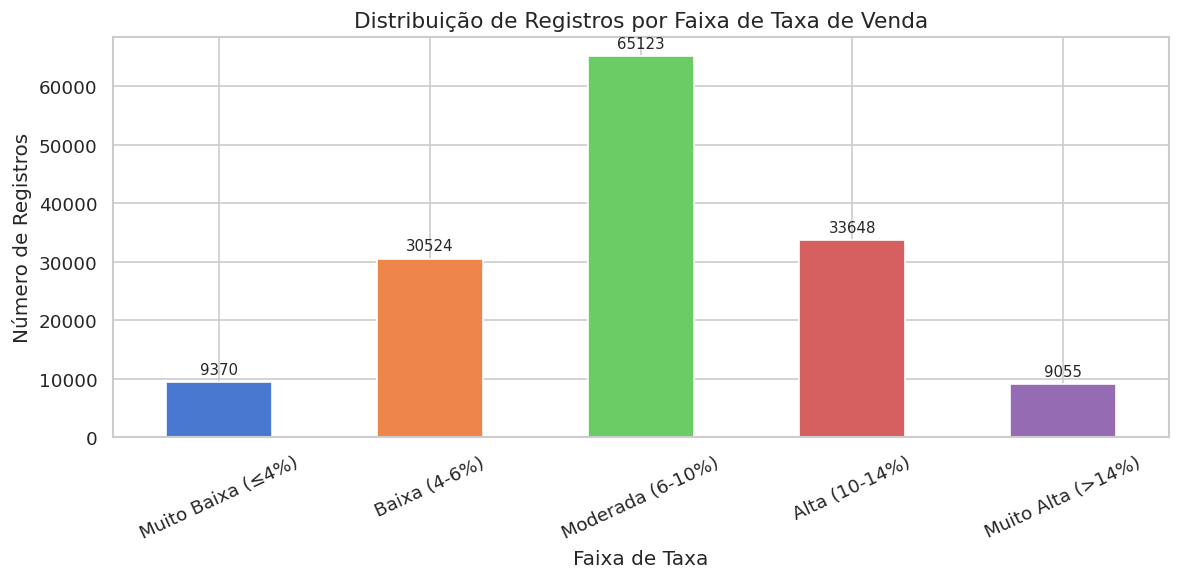

faixa_taxa_venda
Muito Baixa (≤4%)     9370
Baixa (4-6%)         30524
Moderada (6-10%)     65123
Alta (10-14%)        33648
Muito Alta (>14%)     9055


In [17]:
# Definir faixas baseadas no contexto do mercado brasileiro de renda fixa
faixas = [0, 4, 6, 10, 14, float("inf")]
rotulos = ["Muito Baixa (≤4%)", "Baixa (4-6%)", "Moderada (6-10%)",
           "Alta (10-14%)", "Muito Alta (>14%)"]

df_pre["faixa_taxa_venda"] = pd.cut(
    df_pre["Taxa Venda Manha"],
    bins=faixas,
    labels=rotulos,
    right=True,
)

distribuicao_faixas = df_pre["faixa_taxa_venda"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
distribuicao_faixas.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(rotulos)))
ax.set_title("Distribuição de Registros por Faixa de Taxa de Venda", fontsize=13)
ax.set_xlabel("Faixa de Taxa")
ax.set_ylabel("Número de Registros")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print(distribuicao_faixas.to_string())

**Análise após discretização:**

As faixas foram definidas com base nos patamares relevantes para o investidor de renda fixa no Brasil:

- **Muito Baixa (≤4%):** corresponde a taxas reais próximas de zero, típicas de períodos de juro estruturalmente baixo (2020–2021).
- **Baixa (4–6%):** faixa historicamente associada ao piso do ciclo monetário.
- **Moderada (6–10%):** faixa de equilíbrio histórico para títulos prefixados.
- **Alta (10–14%):** ciclos de aperto monetário mais severos.
- **Muito Alta (>14%):** eventos extremos (crise de 2002, pico de 2015–2016).

A concentração em **Moderada** e **Alta** reflete a realidade de um país com histórico de juros reais elevados.

### 4.8 One-Hot Encoding do Tipo de Título

Transformamos a coluna categórica `Tipo Titulo` em variáveis binárias (dummies). Isso é necessário para a maioria dos algoritmos de aprendizado de máquina, que não aceitam dados categóricos diretamente.

In [18]:
df_dummies = pd.get_dummies(df_pre["Tipo Titulo"], prefix="titulo", dtype=int)

print(f"Colunas geradas pelo one-hot encoding: {df_dummies.shape[1]}")
# print(df_dummies.columns.tolist())
df_dummies.head()

Colunas geradas pelo one-hot encoding: 7


,titulo_Tesouro Educa+,titulo_Tesouro IGPM+ com Juros Semestrais,titulo_Tesouro IPCA+,titulo_Tesouro IPCA+ com Juros Semestrais,titulo_Tesouro Prefixado,titulo_Tesouro Prefixado com Juros Semestrais,titulo_Tesouro Renda+ Aposentadoria Extra
0,0,0,0,0,1,0,0
1,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0
4,0,0,0,1,0,0,0


In [19]:
# Dataset final com one-hot encoding integrado (excluindo a coluna original)
df_final = pd.concat(
    [df_pre.drop(columns=["Tipo Titulo"]), df_dummies],
    axis=1,
)

print(f"Dimensões do dataset final: {df_final.shape}")
df_final.head()

Dimensões do dataset final: (148045, 34)


,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha,dias_ate_vencimento,spread_taxa,spread_pu,...,PU Base Manha_std,dias_ate_vencimento_std,faixa_taxa_venda,titulo_Tesouro Educa+,titulo_Tesouro IGPM+ com Juros Semestrais,titulo_Tesouro IPCA+,titulo_Tesouro IPCA+ com Juros Semestrais,titulo_Tesouro Prefixado,titulo_Tesouro Prefixado com Juros Semestrais,titulo_Tesouro Renda+ Aposentadoria Extra
0,2013-01-01,2011-05-11,12.62,12.67,823.01,822.41,822.02,601,0.05,-0.60,...,-0.803748,-0.776877,Alta (10-14%),0,0,0,0,1,0,0
1,2011-07-01,2011-05-11,12.06,12.09,984.30,984.27,983.82,51,0.03,-0.03,...,-0.687137,-0.909164,Alta (10-14%),0,0,0,0,1,0,0
2,2012-01-01,2011-05-11,12.35,12.39,927.87,927.66,927.23,235,0.04,-0.21,...,-0.727922,-0.864908,Alta (10-14%),0,0,0,0,1,0,0
3,2015-01-01,2011-05-11,12.68,12.74,647.02,645.77,645.46,1331,0.06,-1.25,...,-0.930997,-0.601296,Alta (10-14%),0,0,0,0,1,0,0
4,2035-05-15,2011-05-11,5.95,6.05,2118.28,2093.01,2091.99,8770,0.10,-25.27,...,0.111535,1.187944,Moderada (6-10%),0,0,0,1,0,0,0


O one-hot encoding gerou uma coluna binária para cada tipo de título. Ao utilizar esse dataset em modelos lineares, recomenda-se remover uma das colunas (dummy trap) para evitar multicolinearidade perfeita. Para árvores de decisão e modelos baseados em árvores, isso não é necessário.

---
## 5. Análise Exploratória dos Dados (EDA)

### 5.1 Estatísticas Descritivas

In [20]:
# Cópia de trabalho preservando o dataset original
df = df_final.iloc[:, 2:8].copy()

# Resumo estatístico das colunas numéricas
desc = df.describe().T
desc["median"] = df.describe(percentiles=[0.5]).T["50%"]
desc["mode"] = df[desc.index].mode().iloc[0]
desc = desc[["count", "mean", "std", "min", "25%", "median", "75%", "max", "mode"]]
desc.columns = ["N", "Média", "Desvio-Padrão", "Mín", "Q1", "Mediana", "Q3", "Máx", "Moda"]
desc

,N,Média,Desvio-Padrão,Mín,Q1,Mediana,Q3,Máx,Moda
Taxa Compra Manha,148045.0,8.118641,3.444124,-3.53,5.80,7.11,10.71,20.10,6.30
Taxa Venda Manha,148045.0,8.206638,3.432707,-3.41,5.91,7.21,10.79,20.13,5.85
PU Compra Manha,148045.0,1951.503919,1399.634056,0.00,933.61,1497.56,2648.15,9883.96,0.00
PU Venda Manha,148045.0,1937.215055,1387.776888,0.00,930.75,1486.30,2630.02,9808.85,0.00
PU Base Manha,148045.0,1937.233803,1387.521632,0.00,930.73,1486.23,2629.93,9802.55,0.00
dias_ate_vencimento,148045.0,3830.967233,4157.643775,1.00,831.00,2309.00,5522.00,22600.00,149.00


In [21]:
desc = df.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
Taxa Compra Manha,148045.0,8.118641,3.444124,-3.53,5.80,7.11,10.71,20.10
Taxa Venda Manha,148045.0,8.206638,3.432707,-3.41,5.91,7.21,10.79,20.13
PU Compra Manha,148045.0,1951.503919,1399.634056,0.00,933.61,1497.56,2648.15,9883.96
PU Venda Manha,148045.0,1937.215055,1387.776888,0.00,930.75,1486.30,2630.02,9808.85
PU Base Manha,148045.0,1937.233803,1387.521632,0.00,930.73,1486.23,2629.93,9802.55
dias_ate_vencimento,148045.0,3830.967233,4157.643775,1.00,831.00,2309.00,5522.00,22600.00


In [22]:
df.describe(percentiles=[0.5]).T

,count,mean,std,min,50%,max
Taxa Compra Manha,148045.0,8.118641,3.444124,-3.53,7.11,20.10
Taxa Venda Manha,148045.0,8.206638,3.432707,-3.41,7.21,20.13
PU Compra Manha,148045.0,1951.503919,1399.634056,0.00,1497.56,9883.96
PU Venda Manha,148045.0,1937.215055,1387.776888,0.00,1486.30,9808.85
PU Base Manha,148045.0,1937.233803,1387.521632,0.00,1486.23,9802.55
dias_ate_vencimento,148045.0,3830.967233,4157.643775,1.00,2309.00,22600.00


**Análise das Estatísticas Descritivas:**

- As colunas de **taxa** apresentam valores entre -3.41% e aproximadamente 20.13% ao ano, refletindo o amplo período histórico do dataset (ciclos de alta e baixa da taxa Selic).
- Os **preços unitários** variam consideravelmente: Com desvio padrão de R$1399.30, indicando grande dispersão, o que é esperado dado o mix de títulos com diferentes prazos e indexadores.
- A **moda** das taxas e preços não é particularmente informativa dado o comportamento contínuo e evolutivo das séries, porém serve como referência de valor mais frequente no histórico.

### 5.2 Análise de Valores Faltantes e Inconsistentes

In [23]:
# Valores nulos genuínos
nulos = df.isnull().sum()

# Zeros nas colunas numéricas (valores ausentes mascarados)
colunas_numericas = df.select_dtypes(include="number").columns.tolist()
zeros = (df[colunas_numericas] == 0).sum()

print("Valores nulos por coluna:")
print(nulos.to_string())
print()
print("Zeros nas colunas numéricas:")
print(zeros.to_string())

Valores nulos por coluna:
Taxa Compra Manha      0
Taxa Venda Manha       0
PU Compra Manha        0
PU Venda Manha         0
PU Base Manha          0
dias_ate_vencimento    0

Zeros nas colunas numéricas:
Taxa Compra Manha      15
Taxa Venda Manha        1
PU Compra Manha        49
PU Venda Manha         48
PU Base Manha          29
dias_ate_vencimento     0


**Observações:**

- O dataset não apresenta valores `NaN` nativos, porém contém **zeros** nas colunas numéricas.
- A coluna `Tipo Titulo` não apresenta valores ausentes, o que é esperado.

### 5.3 Período Coberto pelo Dataset

In [24]:
data_min = df_pre["Data Base"].min()
data_max = df_pre["Data Base"].max()
periodo = (data_max - data_min).days

print("Período de oferta dos títulos:")
print(f"Data mais antiga : {data_min.strftime('%d/%m/%Y')}")
print(f"Data mais recente: {data_max.strftime('%d/%m/%Y')}")
print(f"Período coberto  : {periodo:,} dias ({periodo / 365.25:.1f} anos)")


janela_titulo = (
    df_pre.groupby("Tipo Titulo")["Data Base"]
    .agg(
        inicio_oferta="min",
        fim_oferta="max"
    )
    .sort_values("inicio_oferta")
    .reset_index()
)

janela_titulo["janela_dias"] = (
    janela_titulo["fim_oferta"] - janela_titulo["inicio_oferta"]
).dt.days

print("\n")
print("Janela de oferta por tipo de título:")
janela_titulo

Período de oferta dos títulos:
Data mais antiga : 31/12/2004
Data mais recente: 20/03/2026
Período coberto  : 7,749 dias (21.2 anos)


Janela de oferta por tipo de título:


,Tipo Titulo,inicio_oferta,fim_oferta,janela_dias
0,Tesouro IGPM+ com Juros Semestrais,2004-12-31,2026-03-20,7749
1,Tesouro IPCA+ com Juros Semestrais,2004-12-31,2026-03-20,7749
2,Tesouro Prefixado,2004-12-31,2026-03-20,7749
3,Tesouro Prefixado com Juros Semestrais,2004-12-31,2026-03-20,7749
4,Tesouro IPCA+,2005-07-18,2026-03-20,7550
5,Tesouro Renda+ Aposentadoria Extra,2023-01-30,2026-03-20,1145
6,Tesouro Educa+,2023-08-01,2026-03-20,962


A janela temporal de oferta não é homogênea entre os tipos de título e isso afeta comparações diretas de representatividade. Enquanto Tesouro Prefixado, Tesouro Prefixado com Juros Semestrais, Tesouro IPCA+ com Juros Semestrais e Tesouro IGPM+ com Juros Semestrais aparecem desde 31/12/2004 até 16/03/2026, o Tesouro IPCA+ inicia em 18/07/2005, e os títulos Tesouro Renda+ Aposentadoria Extra e Tesouro Educa+ surgem apenas a partir de 2023. Portanto, análises baseadas em contagens absolutas tendem a favorecer títulos com maior tempo de exposição no dataset.  
Para comparações mais justas, os dados serão ponderados pela janela temporal de cada tipo de título.

### 5.4 Distribuição dos Tipos de Título

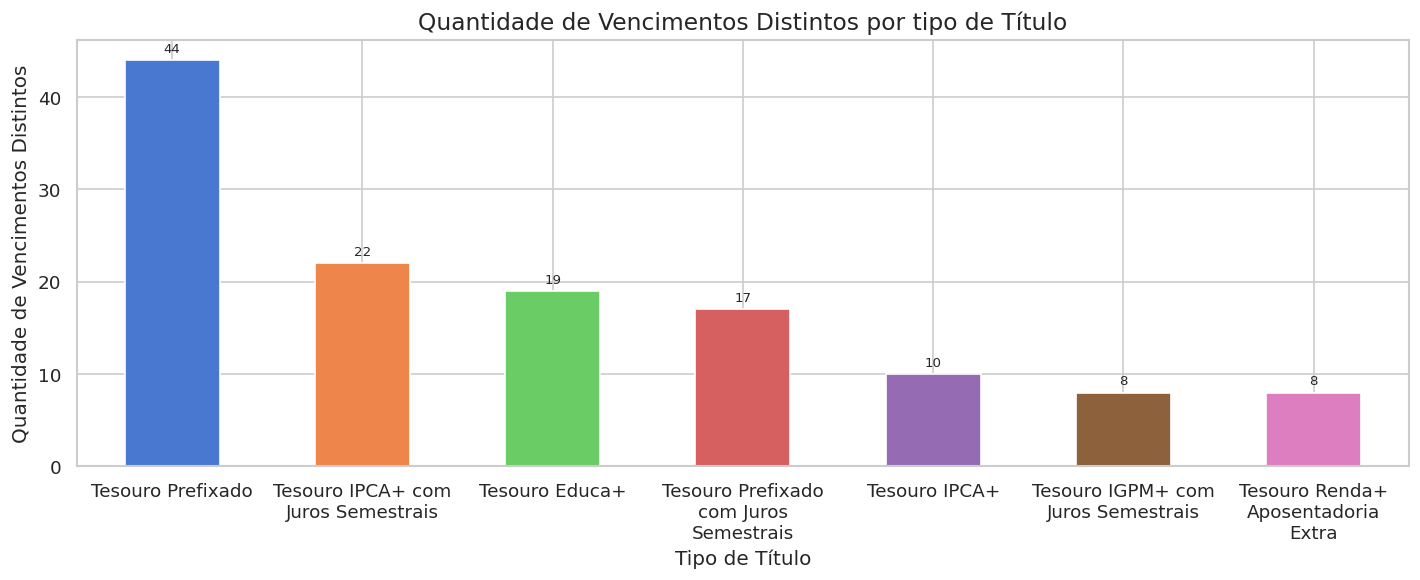

,Tipo Título,Vencimentos Distintos,Janela de Oferta (dias),razao_vencimentos_janela
2,Tesouro Prefixado,44,7749,0.005678
1,Tesouro IPCA+ com Juros Semestrais,22,7749,0.002839
6,Tesouro Educa+,19,962,0.019751
3,Tesouro Prefixado com Juros Semestrais,17,7749,0.002194
4,Tesouro IPCA+,10,7550,0.001325
0,Tesouro IGPM+ com Juros Semestrais,8,7749,0.001032
5,Tesouro Renda+ Aposentadoria Extra,8,1145,0.006987


In [25]:
valores_unicos = (df_pre["Tipo Titulo"] + " - " + df_pre["Data Vencimento"].dt.strftime("%Y-%m-%d")).unique()

valores_unicos = pd.Series([i[:-13] for i in valores_unicos])

contagem_tipos = valores_unicos.value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
contagem_tipos.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(contagem_tipos)))
ax.set_title("Quantidade de Vencimentos Distintos por tipo de Título", fontsize=14)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Quantidade de Vencimentos Distintos")

labels_quebrados = [fill(tipo, width=18) for tipo in contagem_tipos.index]
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels_quebrados, rotation=0, ha="center")

# ax.tick_params(axis="x", rotation=90)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

tabela = pd.DataFrame(contagem_tipos).merge(janela_titulo[["Tipo Titulo",  "janela_dias"]], left_index=True, right_on="Tipo Titulo")[['Tipo Titulo', 'count','janela_dias']]
tabela.columns = ["Tipo Título", "Vencimentos Distintos", "Janela de Oferta (dias)"]
tabela['razao_vencimentos_janela'] = tabela['Vencimentos Distintos'] / tabela['Janela de Oferta (dias)']
tabela

**Análise:**

O gráfico revela que determinados tipos de título possuem muito mais registros que outros, mas temos que ponderar pelo periodo de oferta do título. O mais representado é o `Tesouro Prefixado` com 44 titulos com vencimentos distintos entre os títulos com 7745 dias de oferta. Quando se pondera o número de títulos com vencimentos distintos e a quantidade de dias de ofertatados, o `Tesouro Educa+` e o `Tesouro Renda+ Aposentadoria Extra` são os mais representaitivos, pois apresentão uma quantidade significativa de títulos com vencimentos distintos em relação ao período relativo de oferta. Isso pode indicar uma estratégia do tesouro direto de dar preferencia a esses tipos de títulos, pois o retorno do investimento desses titulos ocorem durante um período de tempo, ao invez de ocorrerem em um momento específico onde o retorno do investimento ocorre no momento do vencimento.

### 5.5 Distribuição das Taxas de Compra e Venda

Os histogramas a seguir mostram a distribuição geral das taxas de compra e venda da manhã.

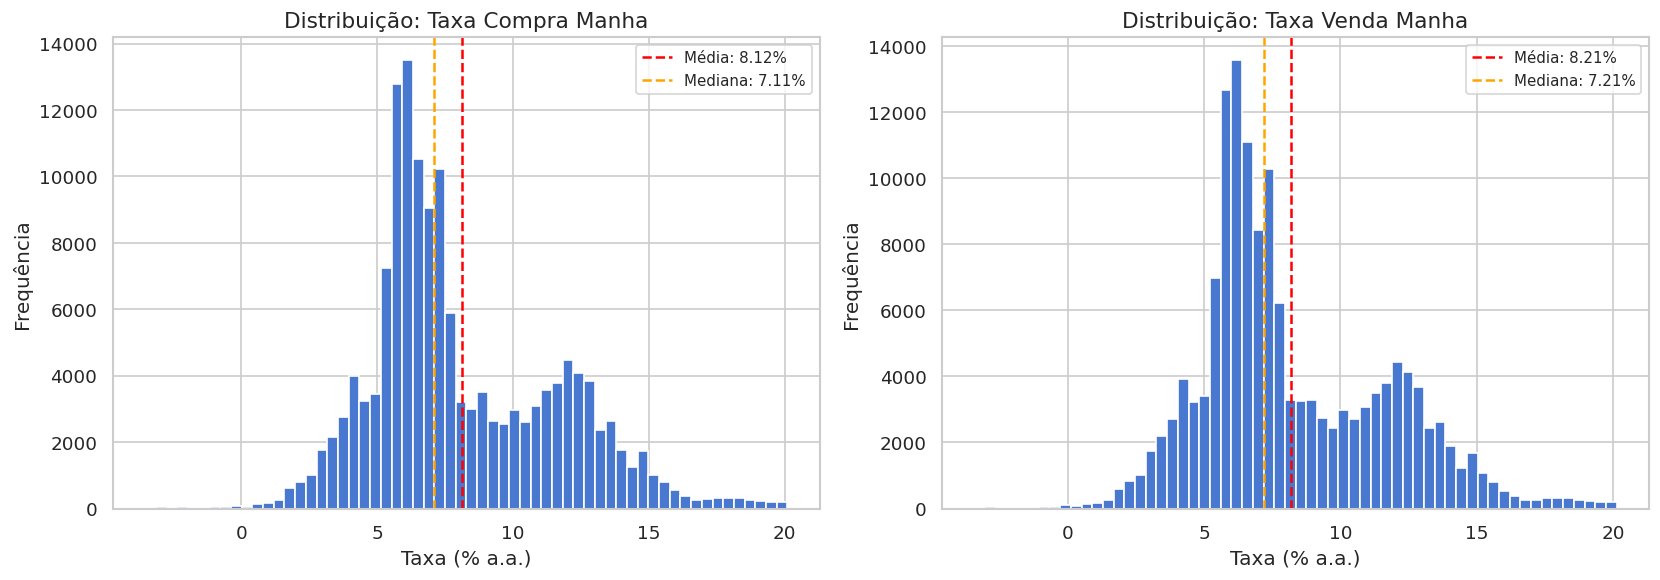

In [26]:
taxas = df_pre[["Taxa Compra Manha", "Taxa Venda Manha"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coluna in zip(axes, ["Taxa Compra Manha", "Taxa Venda Manha"]):
    ax.hist(taxas[coluna], bins=60, edgecolor="white", color=sns.color_palette("muted")[0])
    ax.set_title(f"Distribuição: {coluna}", fontsize=13)
    ax.set_xlabel("Taxa (% a.a.)")
    ax.set_ylabel("Frequência")
    ax.axvline(taxas[coluna].mean(), color="red", linestyle="--", label=f"Média: {taxas[coluna].mean():.2f}%")
    ax.axvline(taxas[coluna].median(), color="orange", linestyle="--", label=f"Mediana: {taxas[coluna].median():.2f}%")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
stat, p_value = stats.wilcoxon(df_pre["Taxa Compra Manha"], df_pre["Taxa Venda Manha"], zero_method='wilcox', correction=False, alternative='two-sided')
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

Estatística de teste: 0.0
Valor-p: 0.00000


**Análise:**

As distribuições das taxas de compra e venda apresentam perfil **multimodal**, com concentrações em diferentes faixas de rentabilidade. Isso é esperado num dataset que mistura tipos distintos de título (prefixados, IPCA+, Selic) ao longo de diferentes ciclos econômicos. A **média** é ligeiramente superior à **mediana**, indicando assimetria positiva — há alguns períodos históricos com taxas muito elevadas (ex.: 2015–2016, quando a taxa Selic chegou a 14,25% a.a.) que puxam a média para cima.  
Apesar da semelhança entre as distribuições de compra e venda, o teste de Wilcoxon confirma que o *spread* entre as duas taxas é significativo. Isso é consistente com a prática de mercado, onde a taxa de venda é geralmente um pouco superior à taxa de compra para cobrir custos operacionais e garantir margem de lucro.

### 5.6 Distribuição dos Preços Unitários

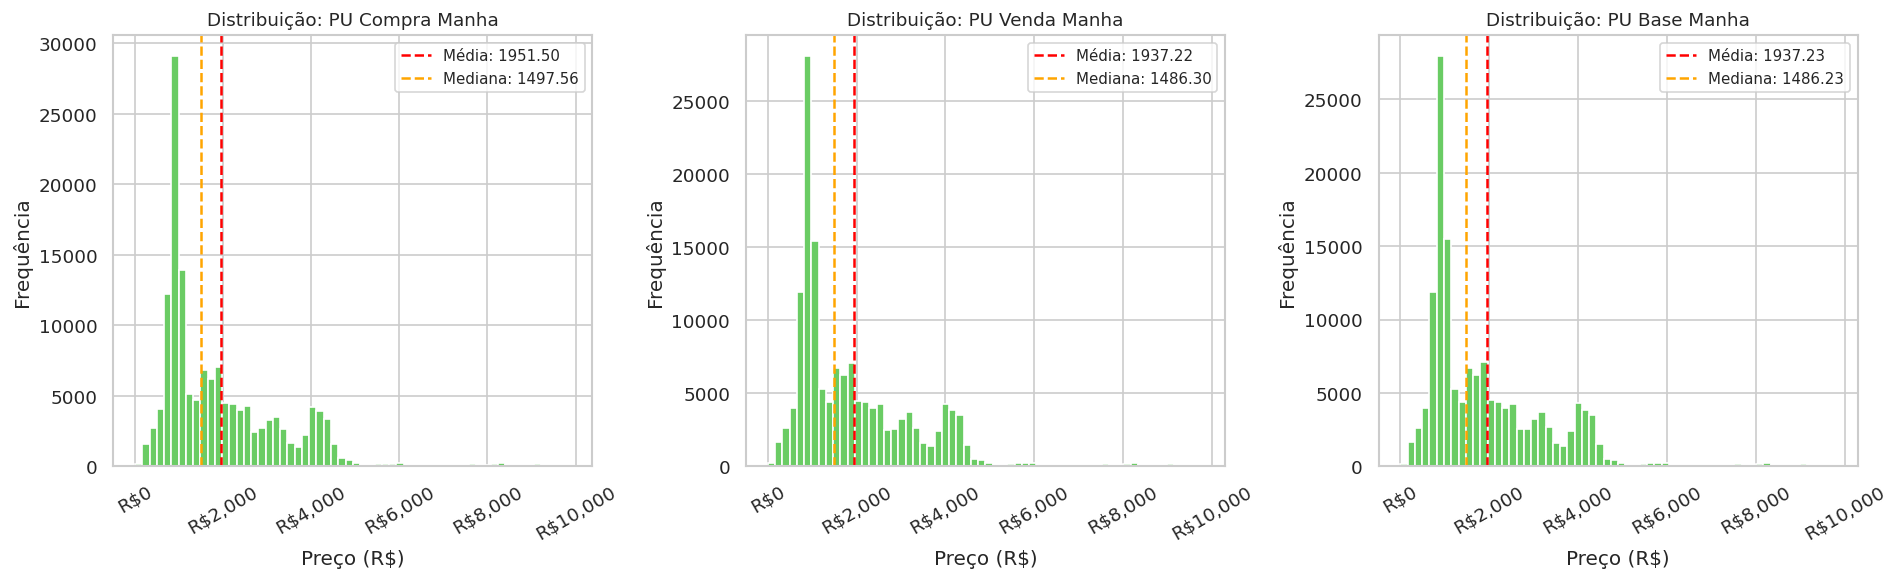

In [28]:
pus = df_pre[["PU Compra Manha", "PU Venda Manha", "PU Base Manha"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, coluna in zip(axes, ["PU Compra Manha", "PU Venda Manha", "PU Base Manha"]):
    ax.hist(pus[coluna], bins=60, edgecolor="white", color=sns.color_palette("muted")[2])
    ax.set_title(f"Distribuição: {coluna}", fontsize=11)
    ax.set_xlabel("Preço (R$)")
    ax.set_ylabel("Frequência")
    ax.axvline(pus[coluna].mean(), color="red", linestyle="--", label=f"Média: {pus[coluna].mean():.2f}")
    ax.axvline(pus[coluna].median(), color="orange", linestyle="--", label=f"Mediana: {pus[coluna].median():.2f}")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [29]:
stat, p_value = stats.friedmanchisquare(
    df_pre["PU Compra Manha"],
    df_pre["PU Venda Manha"],
    df_pre["PU Base Manha"]
)
print("Teste de Friedman para comparação de medianas entre PUs:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")
print("\n")

stat, p_value = stats.kstest(
    df_pre["PU Compra Manha"],
    cdf = stats.lognorm.cdf,
    args = (df_pre["PU Compra Manha"].std(), 0, df_pre["PU Compra Manha"].mean())
)
print("Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Compra Manha:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

stat, p_value = stats.kstest(
    df_pre["PU Venda Manha"],
    cdf = stats.lognorm.cdf,
    args = (df_pre["PU Venda Manha"].std(), 0, df_pre["PU Venda Manha"].mean())
)

print("\n")
print("Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Venda Manha:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

stat, p_value = stats.kstest(
    df_pre["PU Base Manha"],
    cdf = stats.lognorm.cdf,
    args = (df_pre["PU Base Manha"].std(), 0, df_pre["PU Base Manha"].mean())
)

print("\n")
print("Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Base Manha:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

Teste de Friedman para comparação de medianas entre PUs:
Estatística de teste: 272921.1545882921
Valor-p: 0.00000


Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Compra Manha:
Estatística de teste: 0.49953758693567185
Valor-p: 0.00000


Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Venda Manha:
Estatística de teste: 0.4995337163661545
Valor-p: 0.00000


Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Base Manha:
Estatística de teste: 0.4995338180963219
Valor-p: 0.00000


**Análise:**

As distribuições dos preços unitários são fortemente assimétricas, com cauda longa à direita. A maior concentração de registros ocorre em valores relativamente baixos (próximos a R$ 0–R$ 5.000).  
Apesar da assimetria, uma transformação logarítmica não seria útil para alcançar a normalidade nos dados, como indicado pelo teste de Kolmogorov-Smirnov. A normalidade é um pressuposto importante para muitos modelos preditivos, e a falha em alcançar a normalidade implica que técnicas de modelagem robustas ou não paramétricas podem ser mais adequadas para este dataset.  
Apesar da semelhança entre as distribuições, o teste de Friedman indica que há diferenças estatisticamente significativas entre os preços unitários de compra e venda, o que é esperado dado o spread de mercado. A diferença entre os preços unitários de compra e venda é consistente com a prática de mercado, onde o preço de venda é geralmente um pouco superior ao preço de compra para cobrir custos operacionais e garantir margem de lucro.

### 5.7 Análise por Tipo de Título

#### 5.7.1 Séries Temporais de Taxa de Venda

A evolução temporal das taxas é o principal ângulo analítico deste dataset. Analisamos a **Taxa Venda Manha** separada por tipo de título para capturar os ciclos econômicos.

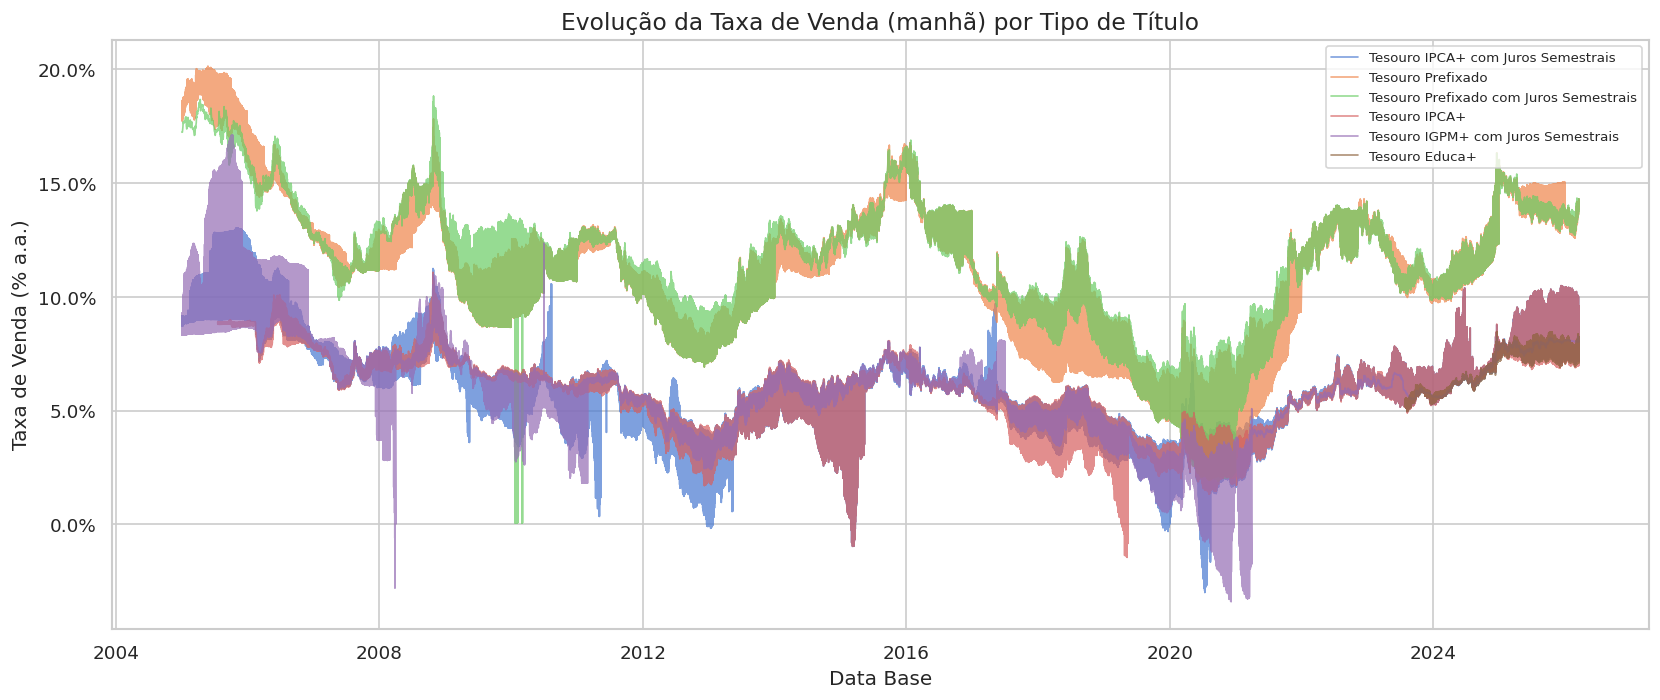

In [30]:
# Filtrar apenas registros com taxa válida
df_taxa = df_pre.copy()

# Selecionar os 6 tipos com mais registros para clareza visual
top_tipos = df_taxa["Tipo Titulo"].value_counts().head(6).index.tolist()
df_top = df_taxa[df_taxa["Tipo Titulo"].isin(top_tipos)]

fig, ax = plt.subplots(figsize=(14, 6))
for tipo in top_tipos:
    subset = df_top[df_top["Tipo Titulo"] == tipo].sort_values("Data Base")
    ax.plot(subset["Data Base"], subset["Taxa Venda Manha"], label=tipo, alpha=0.7, linewidth=1)

ax.set_title("Evolução da Taxa de Venda (manhã) por Tipo de Título", fontsize=14)
ax.set_xlabel("Data Base")
ax.set_ylabel("Taxa de Venda (% a.a.)")
ax.legend(fontsize=8, loc="upper right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}%"))
plt.tight_layout()
plt.show()

**Análise:**

A série temporal revela claramente os **ciclos de política monetária** brasileira:

- **2002–2003:** Elevação abrupta das taxas no período pré-eleição presidencial, com o mercado precificando risco político.
- **2006–2012:** Período de relativa estabilidade e gradual queda das taxas, especialmente no governo Lula.
- **2015–2016:** Novo ciclo de alta, com a taxa Selic atingindo 14,25% a.a. em resposta à crise fiscal e recessão.
- **2017–2019:** Queda expressiva após a recessão, com taxas chegando ao menor nível histórico em 2020.
- **2021–2023:** Nova alta acelerada em resposta à inflação pós-pandemia.

Os títulos indexados (Tesouro IPCA+, Tesouro IPCA+ com Juros Semestrais, Tesouro IGPM+ e Tesouro IGPM+ com Juros Semestrais e Tesouro Educa+) apresentam taxas nominalmente menores, que os títulos prefixados, pois apresentão prazos muito longos que não permitem a modelagem dos riscos de mercado, então eles são indexados a um índice de inflação como IPCA ou IGPM. Já os títulos prefixados embutem a expectativas de inflação futura, o que resulta em taxas mais elevadas.

#### 5.7.2 Análise de Sazonalidade — Melhores Dias para Comprar

A sazonalidade em mercados financeiros pode revelar padrões sistemáticos na Taxa Compra entre diferentes dias da semana e do mês. Esta análise investiga se há dias específicos que oferecem melhores oportunidades para compra de títulos do Tesouro Direto.

##### Análise de Sazonalidade semanal

In [31]:
# Análise agregada por dia da semana
sazon_semana = df_pre.groupby("dia_semana").agg({
    "Taxa Compra Manha": ["mean", "median", "std", "count"],
    "spread_taxa": "mean",
}).round(4)

sazon_semana.columns = ["Taxa Média", "Taxa Mediana", "Desvio Padrão", "N Registros", "Spread Médio"]
sazon_semana = sazon_semana.reindex(["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"])

print("Estatísticas por Dia da Semana:")
print(sazon_semana.to_string())
print()

# Identificar o melhor dia para comprar (menor taxa = melhor para comprador)
melhor_dia = sazon_semana["Taxa Média"].idxmax()
print(f"\n✓ Dia com MAIOR taxa média: {melhor_dia} ({sazon_semana.loc[melhor_dia, 'Taxa Média']:.4f}%)")
print(f"✓ Menor spread médio: {sazon_semana['Spread Médio'].idxmin()} ({sazon_semana['Spread Médio'].min():.6f} p.p.)")

Estatísticas por Dia da Semana:
            Taxa Média  Taxa Mediana  Desvio Padrão  N Registros  Spread Médio
dia_semana                                                                    
Segunda         8.1217          7.10         3.4453      29466.0        0.0880
Terça           8.1182          7.10         3.4440      29569.0        0.0881
Quarta          8.1092          7.11         3.4380      30051.0        0.0878
Quinta          8.1120          7.11         3.4462      29449.0        0.0879
Sexta           8.1323          7.12         3.4474      29510.0        0.0881
Sábado             NaN           NaN            NaN          NaN           NaN
Domingo            NaN           NaN            NaN          NaN           NaN


✓ Dia com MAIOR taxa média: Sexta (8.1323%)
✓ Menor spread médio: Quarta (0.087800 p.p.)


Apesar da Sexta-feira apresentar a maior taxa média, os desvios padrão observados são elevados, o que não permite concluir que a Sexta-feira é o melhor dia para comprar.

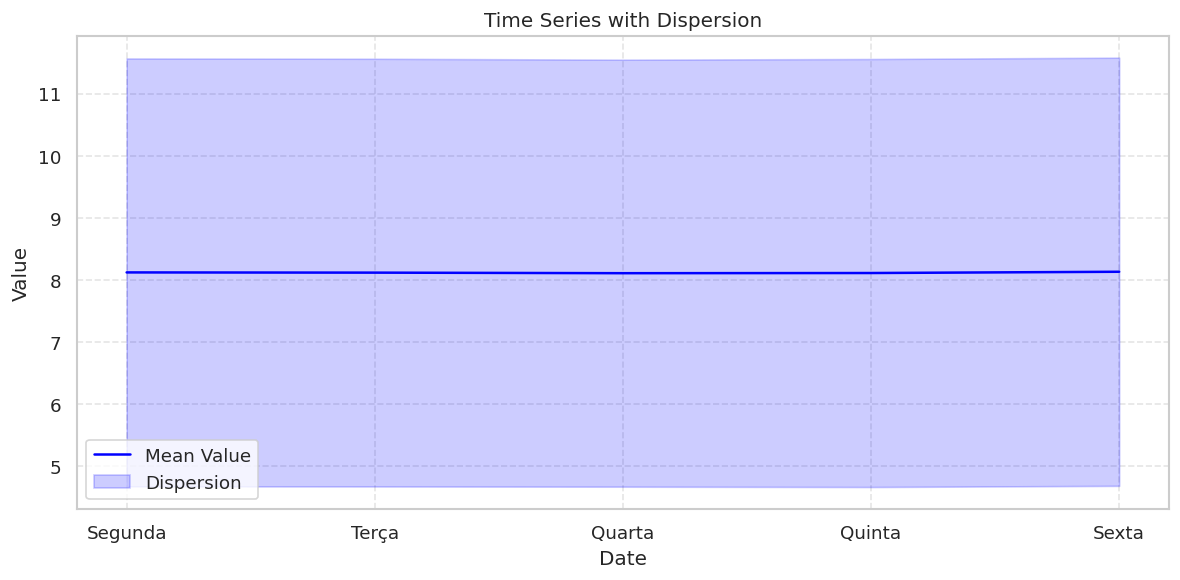

In [32]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(sazon_semana.index, sazon_semana["Taxa Média"], label="Mean Value", color="blue")
plt.fill_between(sazon_semana.index,
                 sazon_semana["Taxa Média"] - sazon_semana["Desvio Padrão"],
                 sazon_semana["Taxa Média"] + sazon_semana["Desvio Padrão"],
                 color="blue", alpha=0.2, label="Dispersion")

plt.title("Time Series with Dispersion")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

O gráfico de dispersão é pouco informativo devido a grande dispersão dos dados.  
Realizamos um teste de ANOVA para verificar se as diferenças entre os dias da semana são estatisticamente significativas, apesar de saber que se trata de uma serie temporal e que a ANOVA não é o teste ideal para dados com autocorrelação temporal, mas mesmo assim, os resultados da ANOVA poderá indicar se há uma possivel diferenças entre os dias da semana.

In [33]:
stat, p_value = stats.f_oneway(
    df_pre[df_pre["dia_semana"] == "Segunda"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Terça"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Quarta"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Quinta"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Sexta"]["Taxa Compra Manha"],
)

print(f"\nTeste ANOVA para diferença de taxas entre dias da semana:")
print(f"Estatística de teste: {stat:.4f}")
print(f"Valor-p: {p_value:.5f}")


Teste ANOVA para diferença de taxas entre dias da semana:
Estatística de teste: 0.2061
Valor-p: 0.93516


Não foram encontradas diferenças estatisticamente significativas entre os dias da semana, o que sugere que a sazonalidade semanal não é um fator relevante para a determinação das taxas de compra. Portanto, não há evidências suficientes para recomendar um dia específico da semana como o melhor momento para comprar títulos do Tesouro Direto com base nas taxas de compra.

In [34]:
sazon_semana

,Taxa Média,Taxa Mediana,Desvio Padrão,N Registros,Spread Médio
dia_semana,,,,,
Segunda,8.1217,7.10,3.4453,29466.0,0.0880
Terça,8.1182,7.10,3.4440,29569.0,0.0881
Quarta,8.1092,7.11,3.4380,30051.0,0.0878
Quinta,8.1120,7.11,3.4462,29449.0,0.0879
Sexta,8.1323,7.12,3.4474,29510.0,0.0881
Sábado,NaN,NaN,NaN,NaN,NaN
Domingo,NaN,NaN,NaN,NaN,NaN


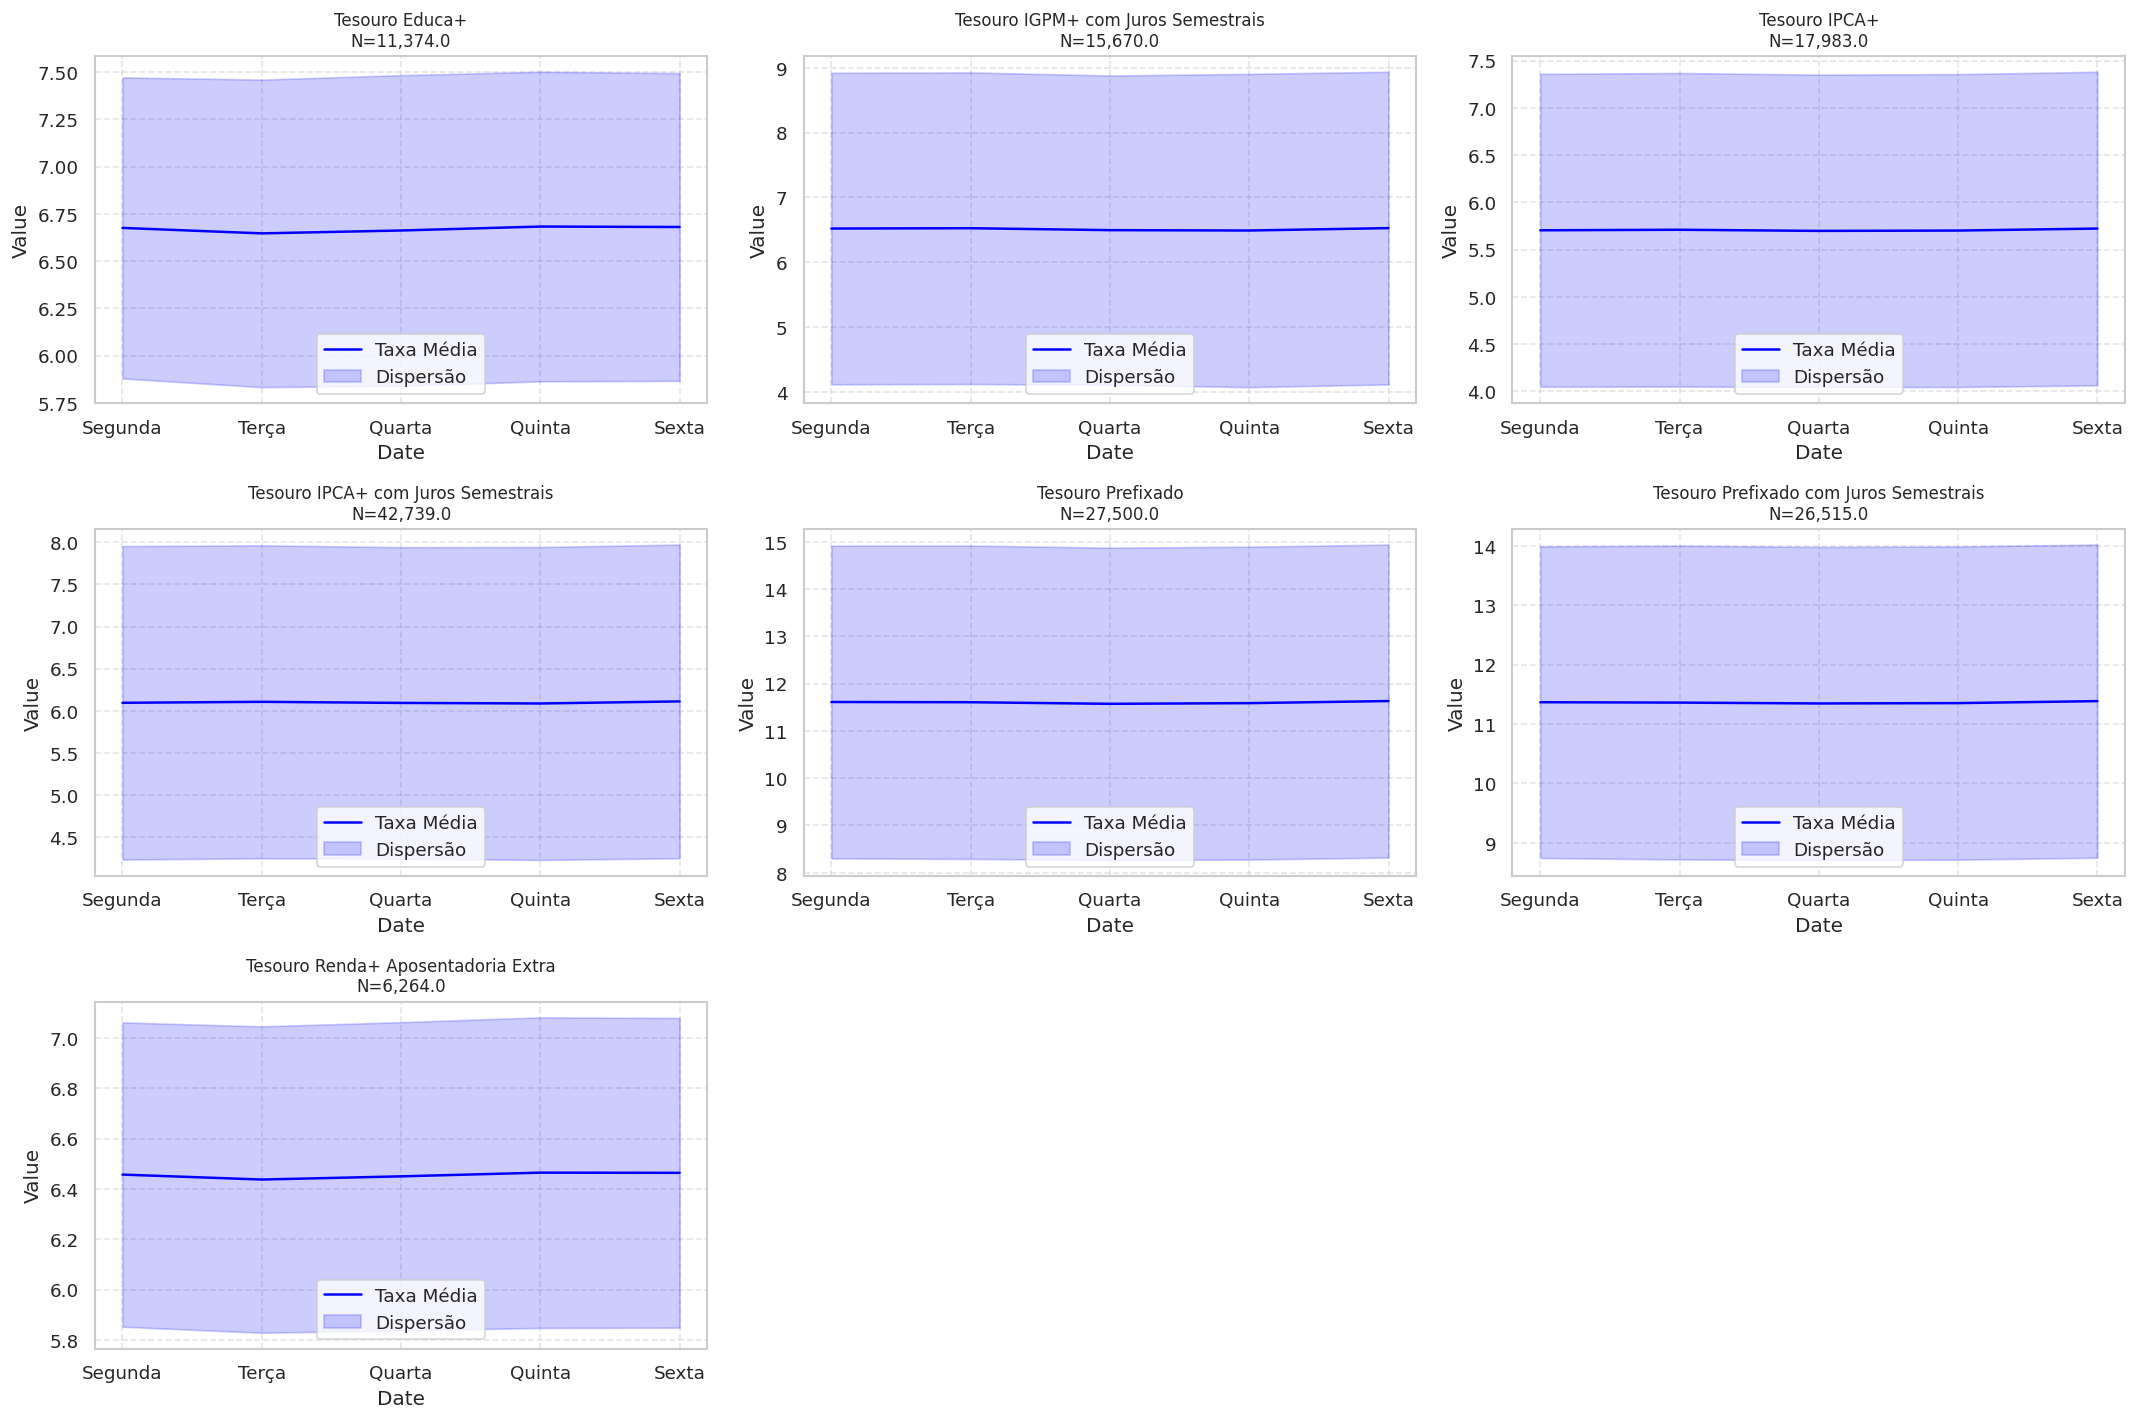

In [35]:
tipos = sorted(df_pre["Tipo Titulo"].dropna().unique())

n_cols = 3
n_rows = int(np.ceil(len(tipos) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)
cor = sns.color_palette("muted")[1]

for i, tipo in enumerate(tipos):
    ax = axes[i]
    sazon_semana = df_pre[df_pre["Tipo Titulo"] == tipo].groupby("dia_semana").agg({
    "Taxa Compra Manha": ["mean", "median", "std", "count"],
    "spread_taxa": "mean",
    }).round(4)
    sazon_semana.columns = ["Taxa Média", "Taxa Mediana", "Desvio Padrão", "N Registros", "Spread Médio"]
    sazon_semana = sazon_semana.reindex(["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"])
    ax.plot(sazon_semana.index, sazon_semana["Taxa Média"], label="Taxa Média", color="blue")
    ax.fill_between(sazon_semana.index,
                     sazon_semana["Taxa Média"] - sazon_semana["Desvio Padrão"],
                     sazon_semana["Taxa Média"] + sazon_semana["Desvio Padrão"],
                     color="blue", alpha=0.2, label="Dispersão")
    ax.set_title(f"{tipo}\nN={sazon_semana['N Registros'].sum():,}", fontsize=10)
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

for j in range(len(tipos), len(axes)):
    axes[j].axis("off")
    
plt.tight_layout()
plt.show()

In [36]:
sazon_semana = df_pre.groupby(["dia_semana", "Tipo Titulo"]).agg({
    "Taxa Compra Manha": ["mean", "median", "std", "count"],
    "spread_taxa": "mean",
}).round(4)
sazon_semana.columns = ["Taxa Média", "Taxa Mediana", "Desvio Padrão", "N Registros", "Spread Médio"]
sazon_semana = sazon_semana.reindex(["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"],
                                    level=0)
# 
# print("Estatísticas por Dia da Semana:")
sazon_semana
# print()

Taxa Média  Taxa Mediana  \
dia_semana Tipo Titulo                                                        
Segunda    Tesouro Educa+                              6.6756         6.900   
           Tesouro IGPM+ com Juros Semestrais          6.5207         6.360   
           Tesouro IPCA+                               5.7040         5.850   
           Tesouro IPCA+ com Juros Semestrais          6.0940         6.080   
           Tesouro Prefixado                          11.6120        11.770   
           Tesouro Prefixado com Juros Semestrais     11.3678        11.780   
           Tesouro Renda+ Aposentadoria Extra          6.4570         6.420   
Terça      Tesouro Educa+                              6.6466         6.780   
           Tesouro IGPM+ com Juros Semestrais          6.5258         6.370   
           Tesouro IPCA+                               5.7097         5.860   
           Tesouro IPCA+ com Juros Semestrais          6.1055         6.100   
           Tesouro Prefixado                          11.6071        11.770   
           Tesouro Prefixado com Juros Semestrais     11.3614        11.780   
           Tesouro Renda+ Aposentadoria Extra          6.4373         6.390   
Quarta     Tesouro Educa+                              6.6619         6.870   
           Tesouro IGPM+ com Juros Semestrais          6.4958         6.360   
           Tesouro IPCA+                               5.6977         5.855   
           Tesouro IPCA+ com Juros Semestrais          6.0925         6.110   
           Tesouro Prefixado                          11.5736        11.760   
           Tesouro Prefixado com Juros Semestrais     11.3471        11.780   
           Tesouro Renda+ Aposentadoria Extra          6.4500         6.410   
Quinta     Tesouro Educa+                              6.6827         6.870   
           Tesouro IGPM+ com Juros Semestrais          6.4903         6.350   
           Tesouro IPCA+                               5.7012         5.840   
           Tesouro IPCA+ com Juros Semestrais          6.0859         6.090   
           Tesouro Prefixado                          11.5880        11.750   
           Tesouro Prefixado com Juros Semestrais     11.3529        11.770   
           Tesouro Renda+ Aposentadoria Extra          6.4647         6.390   
Sexta      Tesouro Educa+                              6.6804         6.950   
           Tesouro IGPM+ com Juros Semestrais          6.5272         6.360   
           Tesouro IPCA+                               5.7225         5.860   
           Tesouro IPCA+ com Juros Semestrais          6.1105         6.090   
           Tesouro Prefixado                          11.6320        11.810   
           Tesouro Prefixado com Juros Semestrais     11.3863        11.810   
           Tesouro Renda+ Aposentadoria Extra          6.4640         6.410   

                                                   Desvio Padrão  N Registros  \
dia_semana Tipo Titulo                                                          
Segunda    Tesouro Educa+                                 0.7969         2265   
           Tesouro IGPM+ com Juros Semestrais             2.4031         3119   
           Tesouro IPCA+                                  1.6550         3579   
           Tesouro IPCA+ com Juros Semestrais             1.8615         8503   
           Tesouro Prefixado                              3.3081         5478   
           Tesouro Prefixado com Juros Semestrais         2.6231         5274   
           Tesouro Renda+ Aposentadoria Extra             0.6043         1248   
Terça      Tesouro Educa+                                 0.8139         2297   
           Tesouro IGPM+ com Juros Semestrais             2.4043         3122   
           Tesouro IPCA+                                  1.6588         3591   
           Tesouro IPCA+ com Juros Semestrais             1.8586         8524   
           Tesouro Prefixado                              3.3152         5

A análise gráfica da sazonalidade semanal também não revelou padrões significativos, indicando que as taxas de compra não apresentam variações sistemáticas ao longo dos dias da semana.

##### Análise de Sazonalidade mensal

In [37]:
# Agrupar em períodos do mês (início, meio, fim)
def classificar_periodo_mes(dia):
    if dia <= 10:
        return "Início (1-10)"
    elif dia <= 20:
        return "Meio (11-20)"
    else:
        return "Fim (21-31)"

df_pre["periodo_mes"] = df_pre["dia_mes"].apply(classificar_periodo_mes)

# Análise por período do mês
sazon_mes = df_pre.groupby("periodo_mes").agg({
    "Taxa Venda Manha": ["mean", "median", "std", "count"],
    "spread_taxa": "mean",
}).round(4)

sazon_mes.columns = ["Taxa Média", "Taxa Mediana", "Desvio Padrão", "N Registros", "Spread Médio"]
sazon_mes = sazon_mes.reindex(["Início (1-10)", "Meio (11-20)", "Fim (21-31)"])

print("\nEstatísticas por Período do Mês:")
print(sazon_mes.to_string())
print()

melhor_periodo = sazon_mes["Taxa Média"].idxmax()
print(f"\n✓ Período com MAIOR taxa média: {melhor_periodo} ({sazon_mes.loc[melhor_periodo, 'Taxa Média']:.4f}%)")


Estatísticas por Período do Mês:
               Taxa Média  Taxa Mediana  Desvio Padrão  N Registros  Spread Médio
periodo_mes                                                                      
Início (1-10)      8.1883          7.19         3.4270        48271        0.0883
Meio (11-20)       8.2054          7.21         3.4238        49131        0.0881
Fim (21-31)        8.2254          7.23         3.4467        50643        0.0876


✓ Período com MAIOR taxa média: Fim (21-31) (8.2254%)


In [38]:
# Agrupar em períodos do mês (início, meio, fim) e por tipo de título
sazon_mes_tipo = df_pre.groupby(["periodo_mes", "Tipo Titulo"]).agg({
    "Taxa Venda Manha": ["mean", "median", "std", "count"],
    "spread_taxa": "mean",
}).round(4)
sazon_mes_tipo.columns = ["Taxa Média", "Taxa Mediana", "Desvio Padrão", "N Registros", "Spread Médio"]
sazon_mes_tipo = sazon_mes_tipo.reindex(["Início (1-10)", "Meio (11-20)", "Fim (21-31)"], level=0)
sazon_mes_tipo

Taxa Média  \
periodo_mes   Tipo Titulo                                          
Início (1-10) Tesouro Educa+                              6.7789   
              Tesouro IGPM+ com Juros Semestrais          6.5846   
              Tesouro IPCA+                               5.7980   
              Tesouro IPCA+ com Juros Semestrais          6.1798   
              Tesouro Prefixado                          11.6739   
              Tesouro Prefixado com Juros Semestrais     11.4237   
              Tesouro Renda+ Aposentadoria Extra          6.5847   
Meio (11-20)  Tesouro Educa+                              6.7908   
              Tesouro IGPM+ com Juros Semestrais          6.5817   
              Tesouro IPCA+                               5.8087   
              Tesouro IPCA+ com Juros Semestrais          6.1811   
              Tesouro Prefixado                          11.6686   
              Tesouro Prefixado com Juros Semestrais     11.4574   
              Tesouro Renda+ Aposentadoria Extra          6.5727   
Fim (21-31)   Tesouro Educa+                              6.7985   
              Tesouro IGPM+ com Juros Semestrais          6.5910   
              Tesouro IPCA+                               5.8045   
              Tesouro IPCA+ com Juros Semestrais          6.1900   
              Tesouro Prefixado                          11.6930   
              Tesouro Prefixado com Juros Semestrais     11.4598   
              Tesouro Renda+ Aposentadoria Extra          6.5664   

                                                      Taxa Mediana  \
periodo_mes   Tipo Titulo                                            
Início (1-10) Tesouro Educa+                                 6.960   
              Tesouro IGPM+ com Juros Semestrais             6.430   
              Tesouro IPCA+                                  5.960   
              Tesouro IPCA+ com Juros Semestrais             6.190   
              Tesouro Prefixado                             11.860   
              Tesouro Prefixado com Juros Semestrais        11.860   
              Tesouro Renda+ Aposentadoria Extra             6.570   
Meio (11-20)  Tesouro Educa+                                 7.080   
              Tesouro IGPM+ com Juros Semestrais             6.430   
              Tesouro IPCA+                                  5.960   
              Tesouro IPCA+ com Juros Semestrais             6.180   
              Tesouro Prefixado                             11.860   
              Tesouro Prefixado com Juros Semestrais        11.870   
              Tesouro Renda+ Aposentadoria Extra             6.510   
Fim (21-31)   Tesouro Educa+                                 6.970   
              Tesouro IGPM+ com Juros Semestrais             6.420   
              Tesouro IPCA+                                  5.940   
              Tesouro IPCA+ com Juros Semestrais             6.170   
              Tesouro Prefixado                             11.835   
              Tesouro Prefixado com Juros Semestrais        11.870   
              Tesouro Renda+ Aposentadoria Extra             6.485   

                                                      Desvio Padrão  \
periodo_mes   Tipo Titulo                                             
Início (1-10) Tesouro Educa+                                 0.8074   
              Tesouro IGPM+ com Juros Semestrais             2.3826   
              Tesouro IPCA+                                  1.6626   
              Tesouro IPCA+ com Juros Semestrais             1.8567   
              Tesouro Prefixado                              3.2991   
              Tesouro Prefixado com Juros Semestrais         2.6351   
              Tesouro Renda+ Aposentadoria Extra             0.5970   
Meio (11-20)  Tesouro Educa+                                 0.8193   
              Tesouro IGPM+ com Juros Semestrais             2.3740   
              Tesouro IPCA+                                  1.6527   
              Tesouro IPCA

A análise de sazonalidade duarante o mês também não revelou padrões significativos, o que sugere que as taxas de compra não apresentam variações sistemáticas ao longo dos dias do mês. Assim como na sazonalidade semanal, isso indica que os padrões sazonais mensais não são um fator relevante para a determinação das taxas de compra dos títulos do Tesouro Direto. Outros fatores, como o cenário macroeconômico e as expectativas de mercado, provavelmente desempenham um papel mais importante na determinação das taxas do que os padrões sazonais.

### 5.8 Análise de Correlação entre Atributos Numéricos

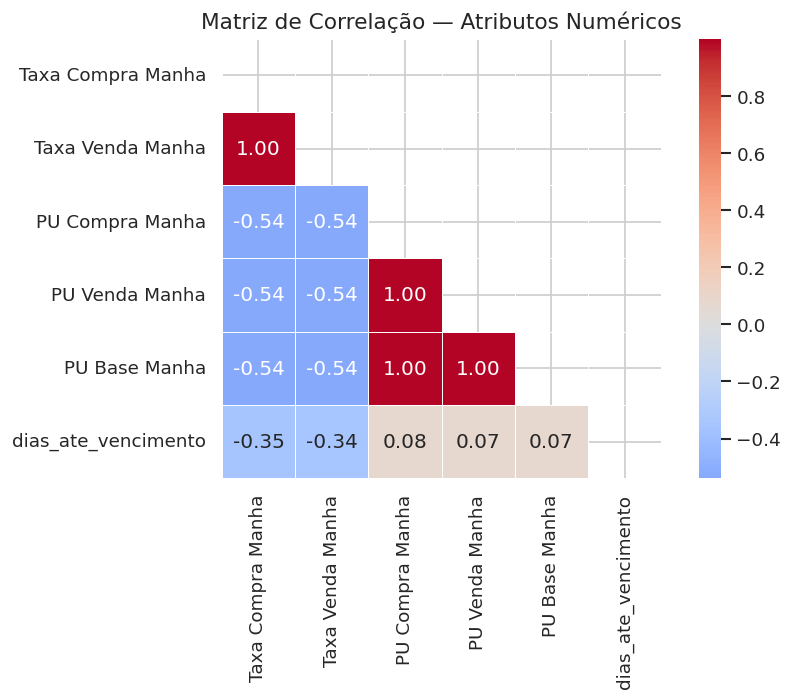

In [39]:
# Substituir zeros por NaN antes de calcular correlação
df_corr = df_pre[colunas_numericas].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=mask,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Matriz de Correlação — Atributos Numéricos", fontsize=13)
plt.tight_layout()
plt.show()

**Análise:**

A matriz de correlação revela padrões importantes:

- **Correlação fortíssima (≈ 1,0) entre PU Compra, PU Venda e PU Base:** os três preços unitários são quase idênticos, diferindo apenas pelo pequeno spread de negociação. Em modelos futuros, utilizar apenas um deles evita multicolinearidade.
- **Correlação fortíssima entre Taxa Compra e Taxa Venda:** assim como os PUs, o spread entre as taxas de compra e venda é mínimo.
- **Correlação negativa entre taxas e preços unitários:** confirma a relação inversa fundamental de renda fixa — quando as taxas sobem, os preços dos títulos caem, e vice-versa.
- **Correlação negativa entre dias até vencimento e taxas:** títulos com vencimentos mais longos tendem a oferecer taxas mais baixas.

As demais correlações são fracas, então não serão consideradas relevantes para a análise.

### 5.9 Violin Plot das Taxas por Tipo de Título

O violin plot permite comparar a dispersão e os outliers das taxas entre os diferentes tipos de título. Esse tipo de gráfico supera o boxplot e o histograma, pois mostra a densidade da distribuição dos dados lado-a-lado, permitindo a comparação das distribuições de forma mais visual e intuitiva. O boxplot, por outro lado, apenas mostra os quartis e os outliers, sem fornecer informações sobre a forma da distribuição.

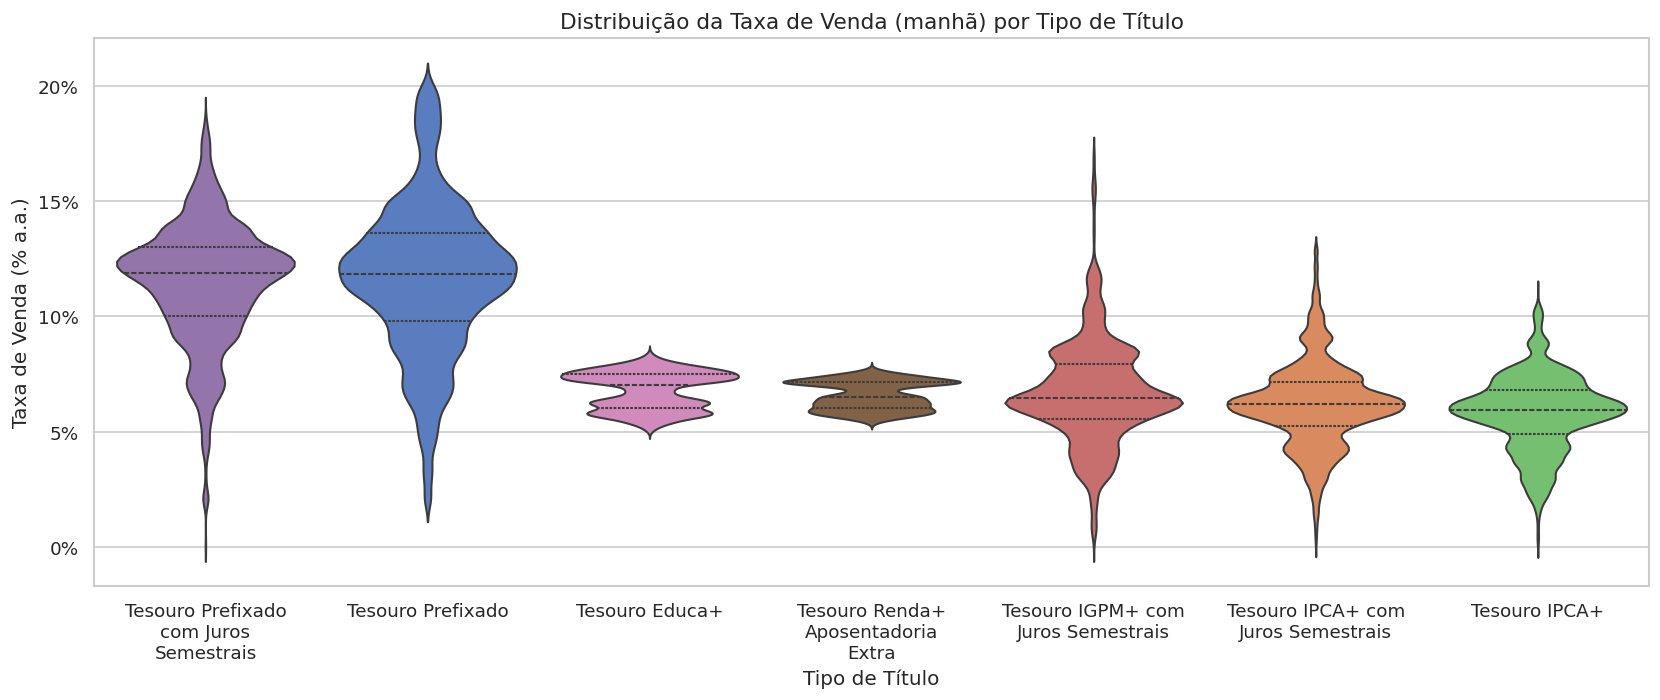

In [40]:
df_box = df_pre[df_pre["Taxa Venda Manha"] > 0].copy()
# Ordenar por mediana para facilitar a leitura
ordem = (
    df_box.groupby("Tipo Titulo")["Taxa Venda Manha"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(
    data=df_box,
    x="Tipo Titulo",
    y="Taxa Venda Manha",
    hue="Tipo Titulo",
    order=ordem,
    palette="muted",
    ax=ax,
    inner="quartile",
)

ax.set_title("Distribuição da Taxa de Venda (manhã) por Tipo de Título", fontsize=13)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Taxa de Venda (% a.a.)")
labels_quebrados = [fill(tipo, width=18) for tipo in ordem]
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels_quebrados, rotation=0, ha="center")
# ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.tight_layout()
plt.show()

**Análise:**

O violin plot destaca diferenças estruturais entre os tipos de título:

- **Tesouro Prefixado:** Esses títulos apresentam maior dispersão, talvez devido à maior sensibilidade a ciclos econômicos e expectativas de inflação, uma vez que apresentão o menor prazo de vencimento, o que os torna ferramentas de controle econômico mais interessantes para políticas monetárias de curto prazo.
- **Tesouro pós-fixado:** Esses títulos (Tesouro IPCA+, Tesouro IPCA+ com Juros Semestrais, Tesouro IGPM+ e Tesouro IGPM+ com Juros Semestrais), por terem prazos mais longos, precisariam ter taxas mais conservadoras devido às incertezas de longo prazo.
- **Tesouro Renda+ Aposentadoria Extra e Tesouro Educa+:** Esses títulos, lançados mais recentemente (Tesouro Renda+ Aposentadoria Extra - 2023-01-30; Tesouro Educa+ - 2023-08-01), apresentam menor disperção, pois a janela temporal de oferta desses títulos é muito curta, e assim não vizitaram uma grande variação de condições econômicas. Contudo, é interessante observar que esses titulos apresentam medianas muito proximas dos demias títulos pós-fixados, o que pode indicar que o tesouro direto deve aplicar a mesma estrategia de taxação para esses titulos, ou seja, aplicar taxas mais conservadoras devido às incertezas de longo prazo, mesmo que a janela temporal de oferta desses títulos seja muito curta.

### 5.10 Análise do Spread entre Taxa de Compra e Venda

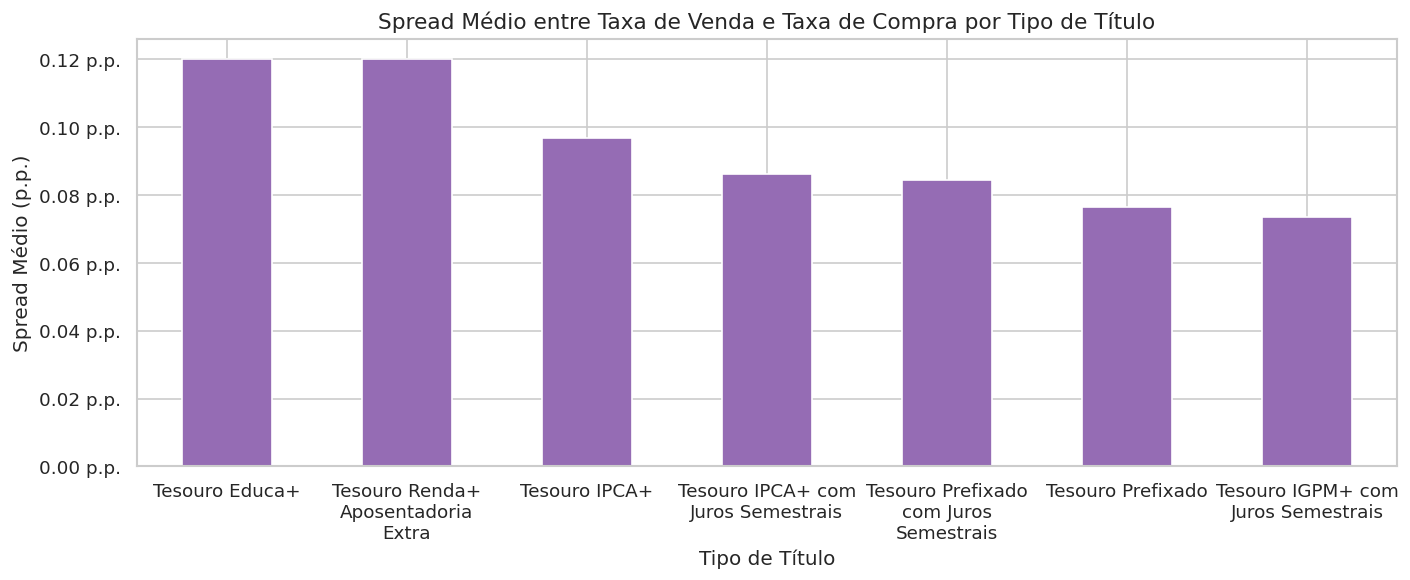

Spread médio (pontos percentuais):
Tipo Titulo
Tesouro Educa+                            0.1200
Tesouro Renda+ Aposentadoria Extra        0.1200
Tesouro IPCA+                             0.0968
Tesouro IPCA+ com Juros Semestrais        0.0861
Tesouro Prefixado com Juros Semestrais    0.0843
Tesouro Prefixado                         0.0763
Tesouro IGPM+ com Juros Semestrais        0.0734


In [41]:
df_spread = df_pre[(df_pre["Taxa Compra Manha"] > 0) & (df_pre["Taxa Venda Manha"] > 0)].copy()
df_spread["spread_taxa"] = df_spread["Taxa Venda Manha"] - df_spread["Taxa Compra Manha"]

# Spread médio por tipo de título
spread_medio = (
    df_spread.groupby("Tipo Titulo")["spread_taxa"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
spread_medio.plot(kind="bar", ax=ax, color=sns.color_palette("muted")[4])
ax.set_title("Spread Médio entre Taxa de Venda e Taxa de Compra por Tipo de Título", fontsize=13)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Spread Médio (p.p.)")
labels_quebrados = [fill(tipo, width=18) for tipo in spread_medio.index]
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels_quebrados, rotation=0, ha="center")
# ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f} p.p."))
plt.tight_layout()
plt.show()

print("Spread médio (pontos percentuais):")
print(spread_medio.round(4).to_string())

**Análise:**

O spread entre as taxas de compra e venda representa o custo implícito de negociação no Tesouro Direto. Os resultados mostram:

- O spread é **muito pequeno** para todos os tipos (geralmente abaixo de 0,10 p.p.), o que evidencia a eficiência e a liquidez razoável do programa.
- Títulos de prazo mais longo tendem a ter spreads maiores, talvez isso seja uma estategia para tornar desinteresse o retorno de título ao Tesouro, garantindo assim uma rolagem da dívida pública por mais tempo.
- Os Tesouro Renda+ Aposentadoria Extra e Tesouro Educa+, que além de serem títulos de longo prazo também apresentão um retrono parcelado, apresentam os maiores spreads, podem ter um interesse maior por parte do tesouro direto, pois dispersa o impacto do vencimento desses títulos no orçamento público, já que o retorno do investimento desses titulos ocorre durante um lomgo período de tempo, ao invés de ocorrerem em um momento específico onde o retorno do investimento ocorre no momento do vencimento.

---
## 6. Checklist — Respostas

### Definição do Problema

| Pergunta | Resposta |
|---|---|
| Qual é a descrição do problema? | Analisar o histórico de preços e taxas dos títulos do Tesouro Direto para entender padrões, tendências e comportamento ao longo de ciclos econômicos. |
| Supervisionado ou não supervisionado? | **Não supervisionado** nesta etapa (EDA e pré-processamento); pode ser reformulado como supervisionado para previsão de taxas. |
| Hipóteses/premissas? | Ver Seção 1.3: H1–H5 |
| Restrições para seleção dos dados? | Todos os registros históricos são usados. Apenas o dado do `Tesouro Selic` foram removidos devido a inconsistências. |
| Atributos definidos? | Ver Seção 1.5: 8 atributos originais + 6 derivados criados no pré-processamento. |

### Análise de Dados

| Pergunta | Resposta |
|---|---|
| Quantos atributos e instâncias? | Verificado na Seção 3.1 (dimensões do dataset) e 3.4 (Tipos de Dados e Informações Gerais) |
| Tipos de dados? | Ver Seção 3.4 (Tipos de Dados e Informações Gerais). |
| Primeiras linhas chamam atenção? | Nada de relevante encontrado. |
| Valores faltantes/discrepantes? | Nada de relevante encontrado. |
| Resumo estatístico realizado? | Sim — Seção 5.1. |
| Distribuição de cada atributo? | Sim — Seções 5.5, 5.6. |
| Análise individual e combinada? | Sim — séries temporais (5.7.1), correlação (5.8), gráfico de violino (5.9), spread (5.10). |

### Pré-processamento

| Operação | Realizada? | Seção |
|---|---|---|
| Análise de inconsistências | ✅ | 4.2 |
| Remoção de inconsistências | ✅ | 4.2 |
| Engenharia de atributos | ✅ | 4.4 |
| Normalização (Min-Max) | ✅ | 4.5 |
| Padronização (Z-score) | ✅ | 4.6 |
| Discretização de taxas | ✅ | 4.7 |
| One-hot encoding | ✅ | 4.8 |

### Respostas às hipóteses e premissas
| Hipótese | Resposta | Seção |
|---|---|---|
| H1: Estratégia de diversificação e suavização do desembolso futuro da dívida pública? | **Confirmada.** A análise da distribuição dos tipos de título e suas janelas temporais sugere que o Tesouro Direto oferece uma variedade de títulos com diferentes prazos e características, o que é consistente com uma estratégia de diversificação e suavização do desembolso futuro da dívida pública. | 5.4 |
| H2: Distribuição de taxas semelhante entre títulos pós-fixados e prefixados? | **Refutada.** O violin plot das taxas por tipo de título revelou que os títulos prefixados apresentam maior dispersão e taxas mais elevadas em comparação com os títulos pós-fixados, que têm taxas mais conservadoras. Isso indica que as distribuições de taxas entre os dois grupos de títulos são diferentes. | 5.5, 5.6 e 5.9 |
| H3: Correlação negativa entre taxa de rentabilidade e preço unitário? | **Confirmada.** A matriz de correlação mostrou uma correlação negativa significativa entre as taxas (compra e venda) e os preços unitários (compra, venda e base), confirmando a relação inversa fundamental de renda fixa. | 5.8 |
| H4: Títulos com prazos de vencimento mais longos oferecem taxas mais elevadas? | **Refutada.** A análise de correlação revelou uma correlação negativa entre dias até vencimento e taxas, indicando que títulos com vencimentos mais longos tendem a oferecer taxas mais baixas, o que é contrário à hipótese inicial. | 5.8 |
| H5: Sazonalidade influencia as taxas? | **Refutada.** As análises de sazonalidade semanal e mensal não revelaram padrões significativos, e os testes estatísticos confirmaram que as diferenças entre os dias da semana e do mês não são estatisticamente significativas. Portanto, a sazonalidade não é um fator relevante para a determinação das taxas de compra. | 5.7 |

---
## 7. Conclusão

Este trabalho percorreu as principais etapas de um projeto de ciência de dados aplicado ao dataset de **Taxas dos Títulos Ofertados pelo Tesouro Direto**. A análise exploratória revelou padrões importantes, como a correlação inversa entre taxas e preços unitários, a diversidade de comportamento entre os tipos de título e a ausência de sazonalidade significativa. Outras analises poderiam ter sido realizadas com o cruzando de informações como dados macroeconômicos, indicadores de inflação e taxas de juros, contudo se compreende que o objetivo deste trabalho era realizar uma análise exploratória e pré-processamento de dados, então essas análises mais avançadas ficaram de fora do escopo deste trabalho. O pré-processamento incluiu a criação de atributos derivados, normalização, padronização, discretização e one-hot encoding, preparando o dataset para futuras etapas de modelagem preditiva.

### Próximos Passos

- **Integração com dados macroeconômicos:** combinar com séries históricas da Selic, IPCA e PIB para enriquecer a análise causal.
- **Modelagem preditiva:** com os dados pré-processados, é possível construir modelos para prever a taxa de um título em função de características como prazo, tipo e momento econômico (ex.: regressão linear, gradient boosting).
- **Análise da serie temporal:** aplicar técnicas de decomposição e modelagem de séries temporais para entender melhor os ciclos e tendências das taxas ao longo do tempo.

---
*Notebook desenvolvido para a disciplina Análise de Dados e Boas Práticas — Especialização em Ciência de Dados, PUC. Todos os dados são públicos e disponibilizados pelo Tesouro Nacional.*